## Import Libraries

In [1]:
# Environment-neutral imports and project configuration
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd

DATA_CANDIDATES = [Path('data/Spotify_data.csv'), Path('../data/Spotify_data.csv')]
DATA_PATH = next((candidate for candidate in DATA_CANDIDATES if candidate.exists()), DATA_CANDIDATES[0])
USE_FULL_DATA = True
RANDOM_SEED = 11
SMOKE_TEST_LIMIT = None  # Set to a small number, such as 5000, for quick local smoke runs.
ENABLE_GRID_SEARCH = False  # Full-data cross-validation is expensive; enable only on a capable machine.


##Load Dataset

In [2]:
# Validate dataset path before starting the Spark workflow
print('Checking dataset path...')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')
print(f'Dataset found: {DATA_PATH.resolve()}')


Checking dataset path...
Dataset found: C:\Users\SampathNagaMaddineni\Documents\UNT\IBD\Project\main\data\Spotify_data.csv


##Install PySpark

In [3]:
# Optional Colab setup. Local Jupyter users should install requirements.txt instead.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Colab detected. Installing PySpark if needed...')
    %pip install -q pyspark
else:
    print('Local Jupyter detected. Using installed dependencies from requirements.txt.')


Local Jupyter detected. Using installed dependencies from requirements.txt.


## Import Libraries and Initialize Spark

In [4]:
# Import Spark libraries and initialize a local Spark session
from pyspark.sql import SparkSession
from pyspark.sql import functions as fn
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import PCA, StandardScaler, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import FloatType

import matplotlib.pyplot as plt
import seaborn as sns

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = (
    SparkSession.builder
    .appName('MusicDataAnalysisRecommendation')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')
    .config('spark.pyspark.python', sys.executable)
    .config('spark.pyspark.driver.python', sys.executable)
    .getOrCreate()
)

raw_spark_df = (
    spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(str(DATA_PATH))
)

if SMOKE_TEST_LIMIT:
    raw_spark_df = raw_spark_df.limit(SMOKE_TEST_LIMIT)

raw_spark_df = raw_spark_df.cache()
print(f'Loaded rows with Spark: {raw_spark_df.count():,}')
print(f'Columns: {len(raw_spark_df.columns)}')
raw_spark_df.printSchema()


Loaded rows with Spark: 169,909
Columns: 19
root
 |-- acousticness: double (nullable = true)
 |-- artists: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- id: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- key: string (nullable = true)
 |-- liveness: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- tempo: string (nullable = true)
 |-- valence: string (nullable = true)
 |-- year: string (nullable = true)



##Data Loading and Preprocessing

In [5]:
# Build the main Spark DataFrame. Full data is the default for this Big Data project.
numeric_columns = [
    'acousticness', 'danceability', 'duration_ms', 'energy', 'explicit',
    'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity',
    'speechiness', 'tempo', 'valence', 'year'
]

clean_spark_df = raw_spark_df
for column_name in numeric_columns:
    clean_spark_df = clean_spark_df.withColumn(column_name, fn.col(column_name).cast('double'))

base_spark_df = clean_spark_df if USE_FULL_DATA else clean_spark_df.filter(fn.col('year') >= 2015)
raw_modeling_rows = base_spark_df.count()
base_spark_df = base_spark_df.dropna(subset=numeric_columns).cache()
print(f'Dropped rows with invalid numeric values: {raw_modeling_rows - base_spark_df.count():,}')
music_df = base_spark_df.drop('id').cache()
music_with_id_df = base_spark_df.cache()

# Keep a recent-years Pandas slice only for comparison plots and lightweight local visuals.
music_2015_2020 = clean_spark_df.filter(fn.col('year') >= 2015).drop('id').toPandas()
raw_data = clean_spark_df.toPandas()
for column_name in numeric_columns:
    if column_name in music_2015_2020.columns:
        music_2015_2020[column_name] = pd.to_numeric(music_2015_2020[column_name], errors='coerce')
    if column_name in raw_data.columns:
        raw_data[column_name] = pd.to_numeric(raw_data[column_name], errors='coerce')

print(f'Main modeling rows: {music_df.count():,}')
print(f'Recent-years comparison rows: {len(music_2015_2020):,}')


Dropped rows with invalid numeric values: 1,447


Main modeling rows: 168,462
Recent-years comparison rows: 11,639


##Data Exploration

In [6]:
# Check data types
print("Data Types:")
print(music_df.dtypes)

# Show basic statistics
print("Descriptive Statistics:")
music_df.describe().show()


Data Types:
[('acousticness', 'double'), ('artists', 'string'), ('danceability', 'double'), ('duration_ms', 'double'), ('energy', 'double'), ('explicit', 'double'), ('instrumentalness', 'double'), ('key', 'double'), ('liveness', 'double'), ('loudness', 'double'), ('mode', 'double'), ('name', 'string'), ('popularity', 'double'), ('release_date', 'string'), ('speechiness', 'double'), ('tempo', 'double'), ('valence', 'double'), ('year', 'double')]
Descriptive Statistics:


+-------+-------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+----------------------------+------------------+------------------+-------------------+------------------+------------------+-----------------+
|summary|       acousticness|             artists|       danceability|       duration_ms|            energy|           explicit|   instrumentalness|              key|           liveness|          loudness|              mode|                        name|        popularity|      release_date|        speechiness|             tempo|           valence|             year|
+-------+-------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+----------------------------+-----------

In [7]:
# Convert to Pandas DataFrame for correlation and covariance
music_pd = music_df.toPandas()

# Convert all numeric columns to proper numeric types
for col in music_pd.select_dtypes(include=['object']).columns:
    music_pd[col] = pd.to_numeric(music_pd[col], errors='coerce')

# Drop columns with all NaN values after conversion
music_pd = music_pd.dropna(axis=1, how='all')


In [8]:

# Correlation matrix
print("Correlation Matrix:")
print(music_pd.corr())

# Covariance matrix
print("Covariance Matrix:")
print(music_pd.cov())


Correlation Matrix:
                  acousticness  danceability  duration_ms    energy  explicit  \
acousticness          1.000000     -0.259177    -0.081448 -0.748602 -0.252450   
danceability         -0.259177      1.000000    -0.133288  0.213590  0.241002   
duration_ms          -0.081448     -0.133288     1.000000  0.037983 -0.044263   
energy               -0.748602      0.213590     0.037983  1.000000  0.141044   
explicit             -0.252450      0.241002    -0.044263  0.141044  1.000000   
instrumentalness      0.338739     -0.282069     0.083818 -0.290141 -0.138674   
key                  -0.021034      0.022474    -0.003161  0.029583  0.008628   
liveness             -0.025889     -0.105581     0.035964  0.128501  0.040116   
loudness             -0.565109      0.288289    -0.014777  0.782198  0.151303   
mode                  0.046057     -0.045178    -0.048125 -0.037978 -0.083229   
name                 -0.070259     -0.145591    -0.237897 -0.070383 -0.052666   
populari

                  acousticness  danceability   duration_ms        energy  \
acousticness      1.414272e-01 -1.703626e-02 -3.696746e+03 -7.517160e-02   
danceability     -1.703626e-02  3.055080e-02 -2.811734e+03  9.968492e-03   
duration_ms      -3.696746e+03 -2.811734e+03  1.456605e+10  1.224032e+03   
energy           -7.517160e-02  9.968492e-03  1.224032e+03  7.129727e-02   
explicit         -2.652749e-02  1.177030e-02 -1.492668e+03  1.052316e-02   
instrumentalness  3.939885e-02 -1.524818e-02  3.128661e+03 -2.396059e-02   
key              -2.780752e-02  1.380945e-02 -1.341074e+03  2.776889e-02   
liveness         -1.720178e-03 -3.260520e-03  7.668858e+02  6.062223e-03   
loudness         -1.199147e+00  2.843237e-01 -1.006278e+04  1.178493e+00   
mode              7.872821e-03 -3.589274e-03 -2.640051e+03 -4.609278e-03   
name             -1.195355e+09 -1.478124e+09 -9.850895e+14 -8.718464e+08   
popularity       -4.773903e+00  8.060257e-01  1.687417e+05  2.837350e+00   
release_date

In [9]:

# Check for null values in the PySpark DataFrame
from pyspark.sql.functions import col, count, when, isnull, isnan

print("Null Values Count:")
music_df.select([count(when(isnull(c), c)).alias(c) for c in music_df.columns]).show()

print("NaN Values Count:")
music_df.select([count(when(isnan(col(c)), c)).alias(c) for c in music_df.columns]).show()


Null Values Count:


+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|acousticness|artists|danceability|duration_ms|energy|explicit|instrumentalness|key|liveness|loudness|mode|name|popularity|release_date|speechiness|tempo|valence|year|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|           0|      0|           0|          0|     0|       0|               0|  0|       0|       0|   0|   0|         0|           0|          0|    0|      0|   0|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+

NaN Values Count:


+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|acousticness|artists|danceability|duration_ms|energy|explicit|instrumentalness|key|liveness|loudness|mode|name|popularity|release_date|speechiness|tempo|valence|year|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|           0|      0|           0|          0|     0|       0|               0|  0|       0|       0|   0|   0|         0|           0|          0|    0|      0|   0|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+



##Pair Plot Visualiz

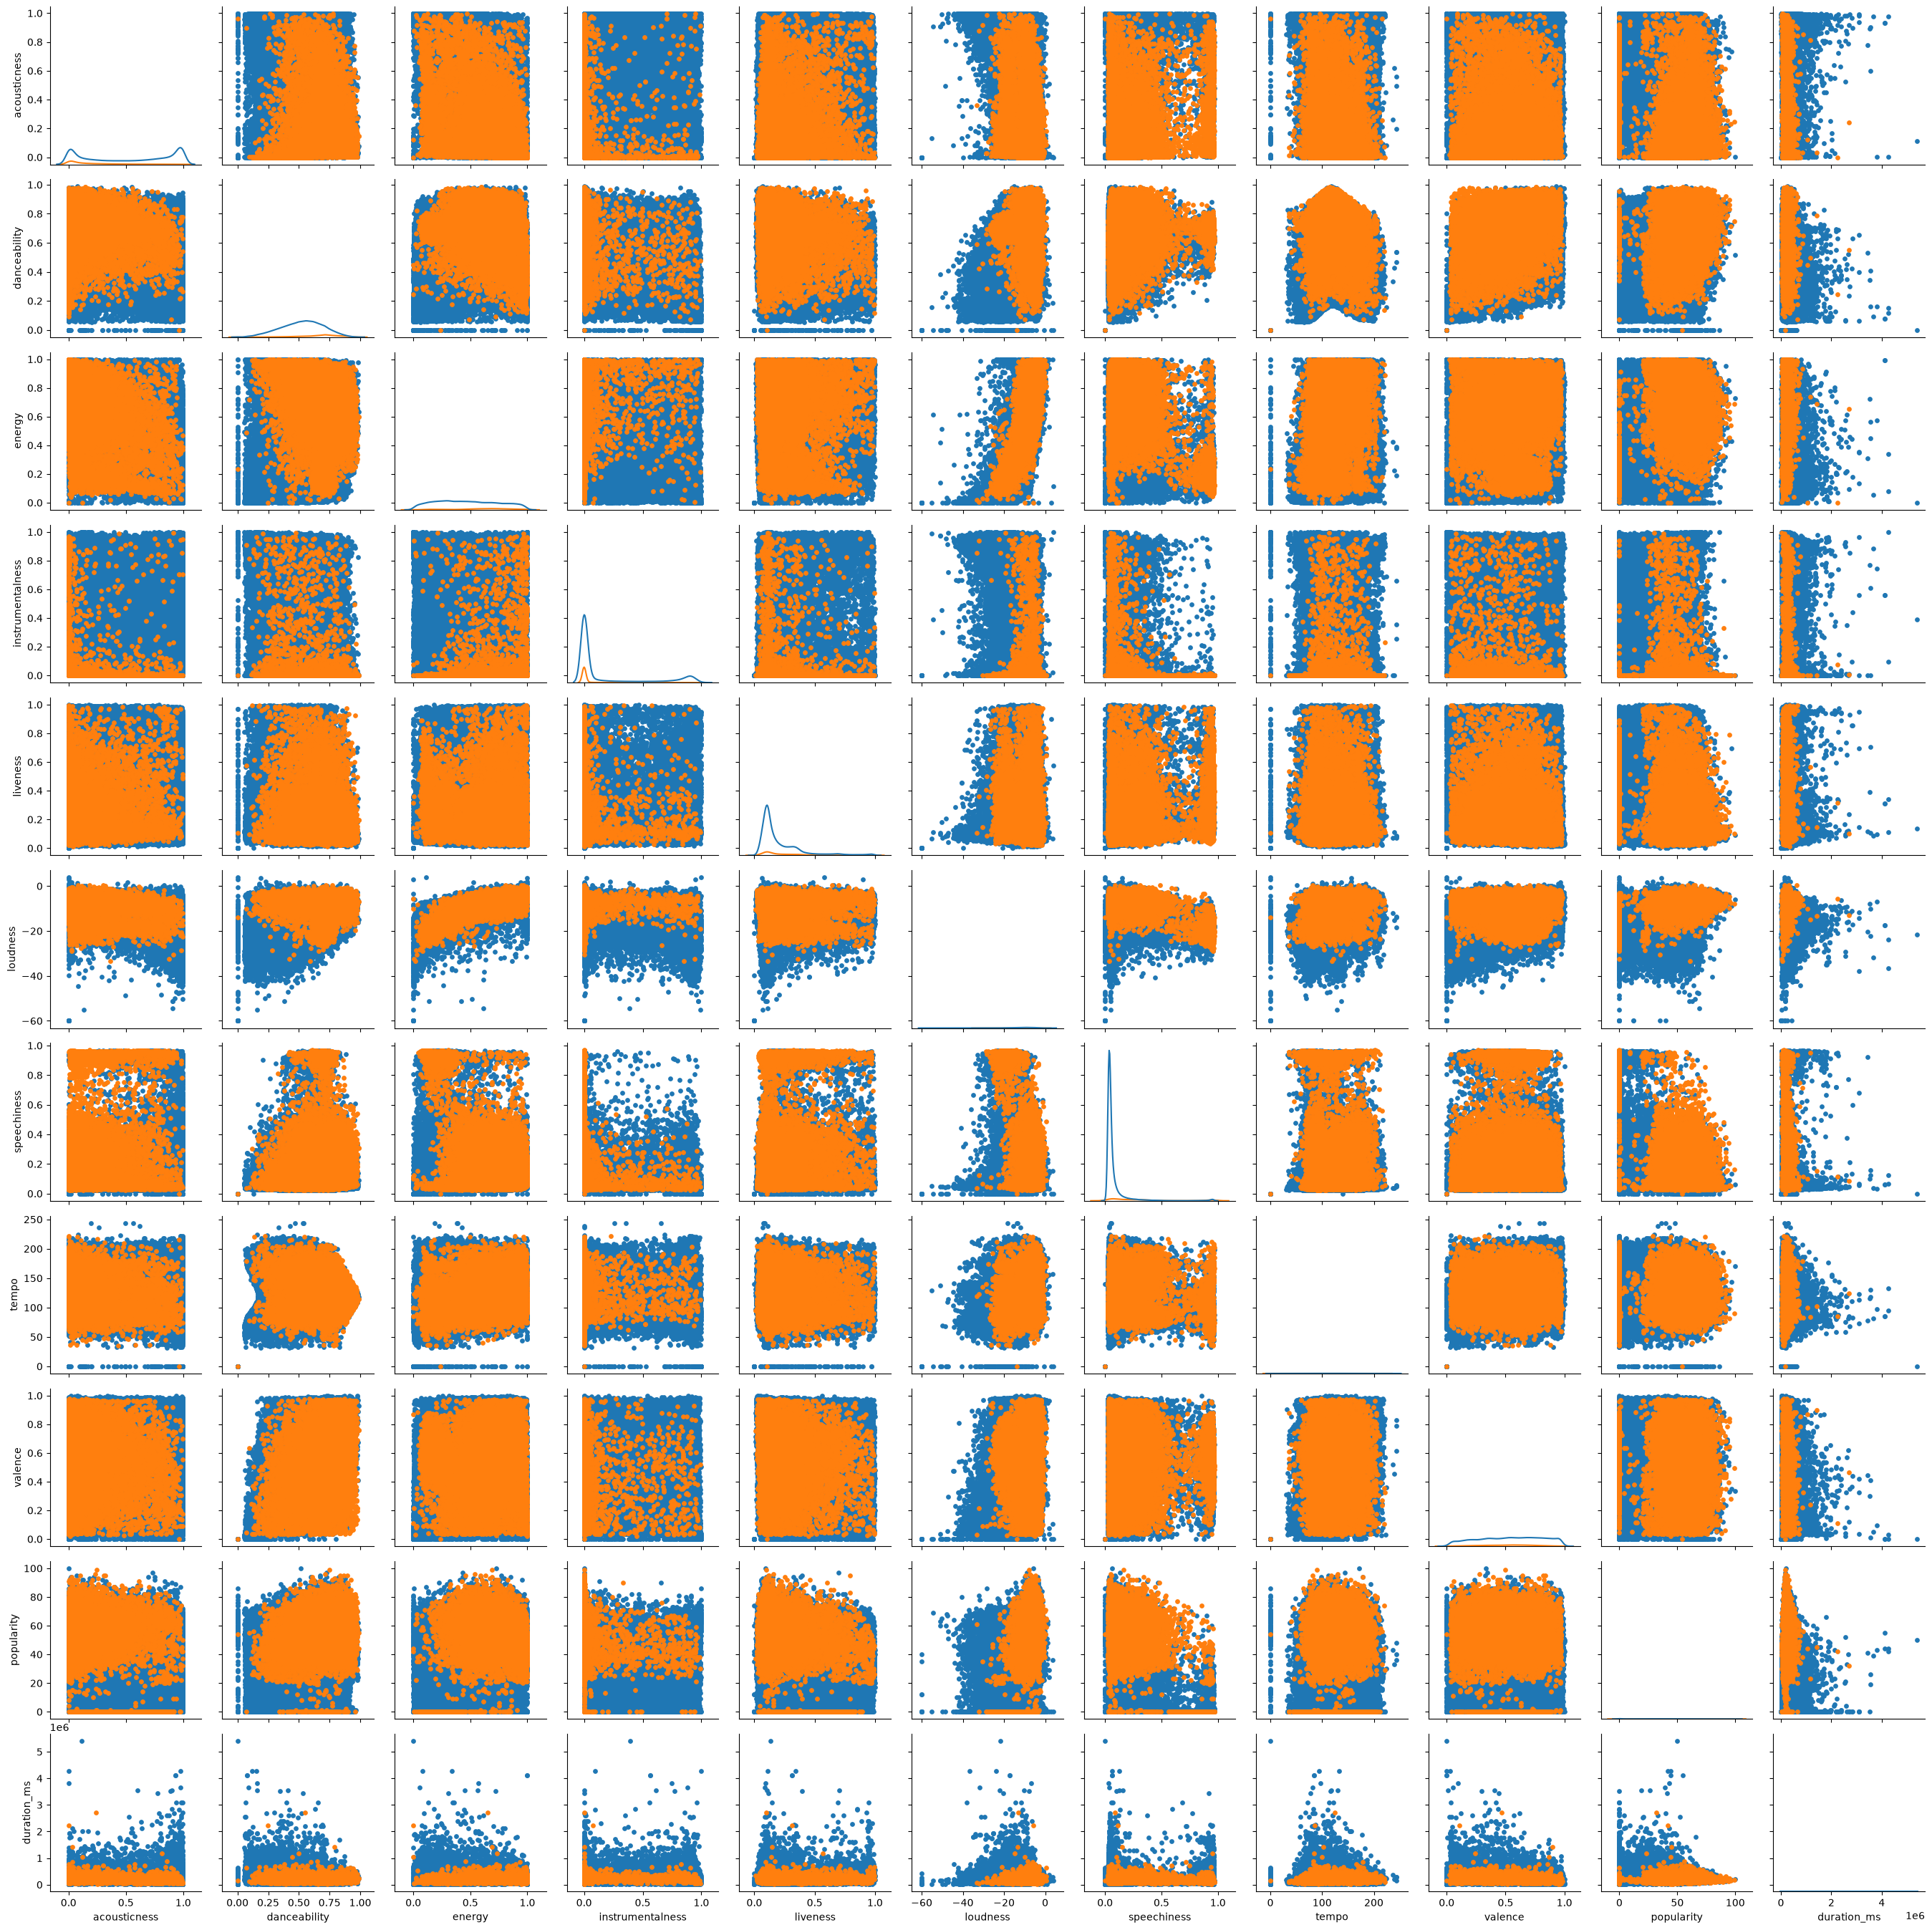

In [10]:
# Pair Grid Visualization
p = sns.PairGrid(music_pd, vars=['acousticness', 'danceability', 'energy',
                                 'instrumentalness', 'liveness', 'loudness',
                                 'speechiness', 'tempo', 'valence', 'popularity',
                                 'duration_ms'], hue='explicit')
p.map_diag(sns.kdeplot)  # Kernel density on diagonal
p.map_offdiag(plt.scatter, s=15)  # Scatter plot on off-diagonal


##Popularity Distribution Visualization

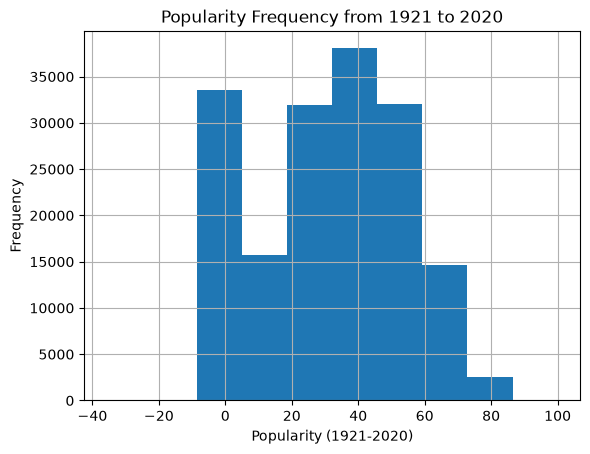

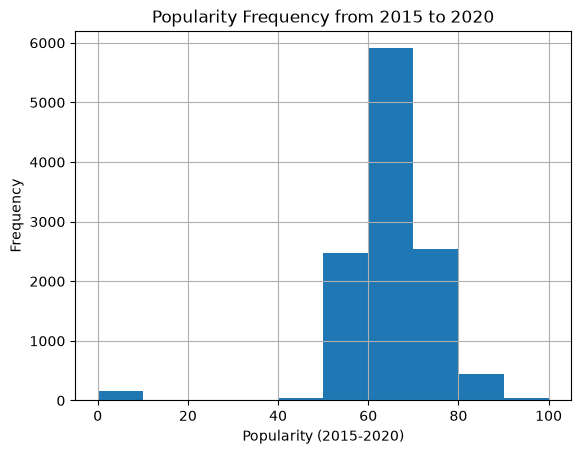

In [11]:
# Popularity distribution from the original data (1921 - 2020)
raw_data['popularity'].hist()
plt.xlabel('Popularity (1921-2020)')
plt.ylabel('Frequency')
plt.title('Popularity Frequency from 1921 to 2020')
plt.show()

# Popularity distribution from the recent data (2015 - 2020)
music_2015_2020['popularity'].hist()
plt.xlabel('Popularity (2015-2020)')
plt.ylabel('Frequency')
plt.title('Popularity Frequency from 2015 to 2020')
plt.show()


##Annual Trend Analysis

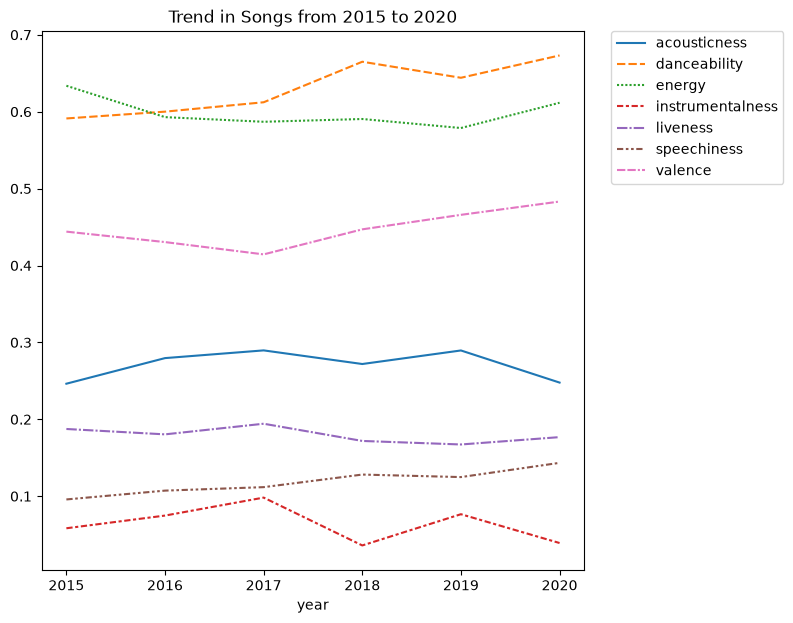

In [12]:
# Isolate numeric columns for analysis
music_num = music_2015_2020.drop(['artists', 'explicit', 'mode', 'name',
                                  'release_date', 'key'], axis=1)

# Analyze trends by year
year_trend = music_num.groupby('year').mean().drop(['duration_ms', 'tempo',
                                                    'popularity', 'loudness'], axis=1)

# Plot yearly trend
plt.figure(figsize=(7, 7))
sns.lineplot(data=year_trend)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Trend in Songs from 2015 to 2020')
plt.show()


##Popularity vs Other Features

C:\Users\SampathNagaMaddineni\AppData\Local\Temp\ipykernel_28848\967460485.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


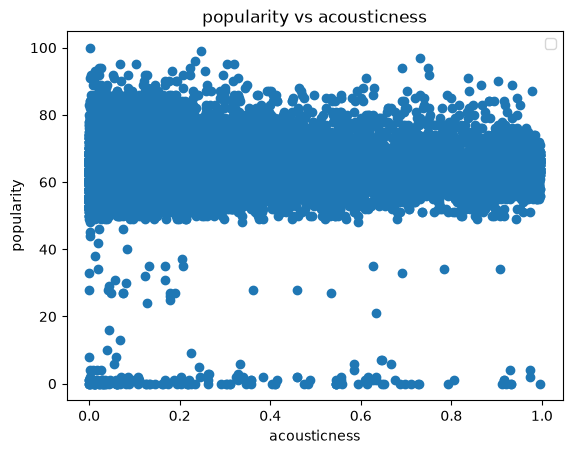

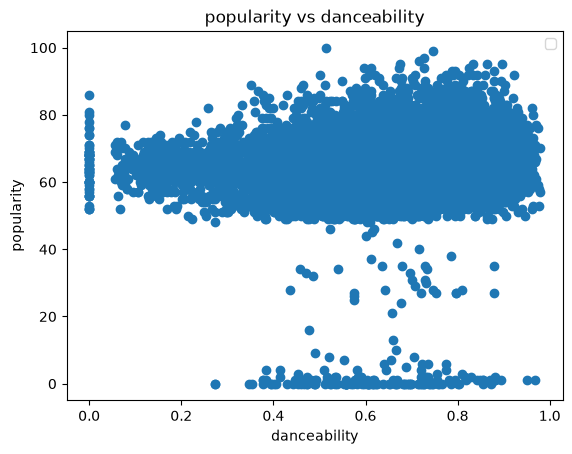

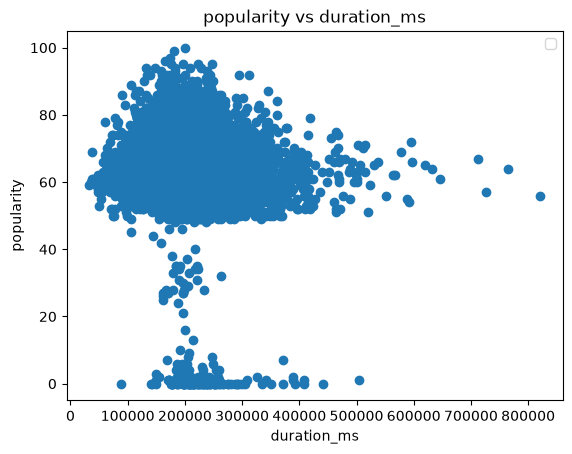

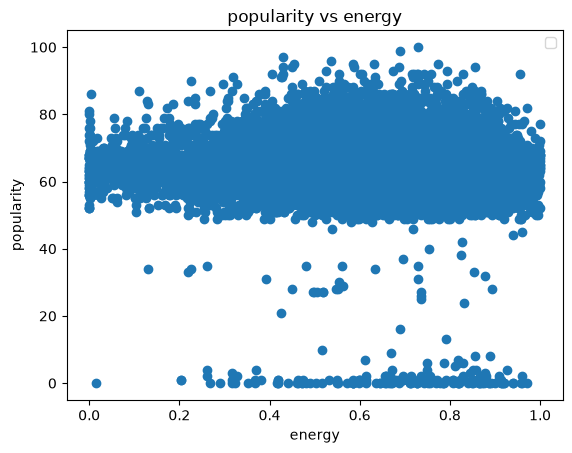

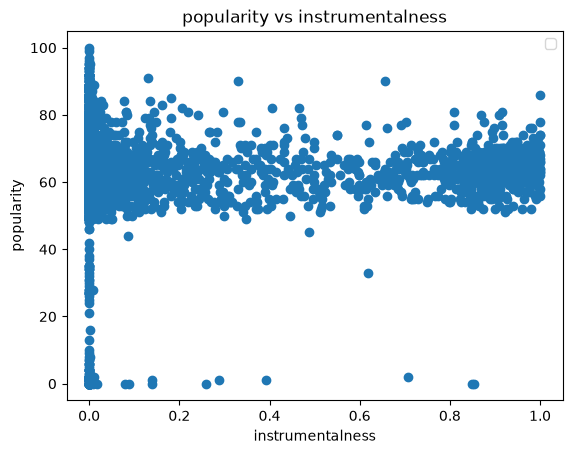

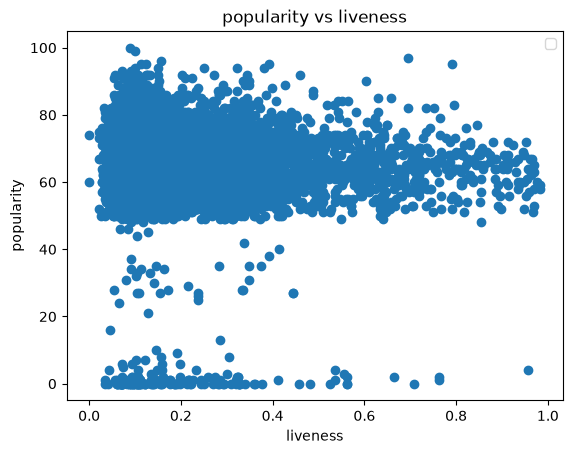

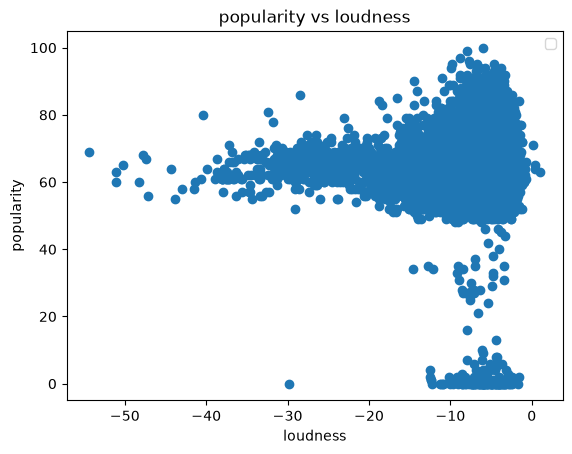

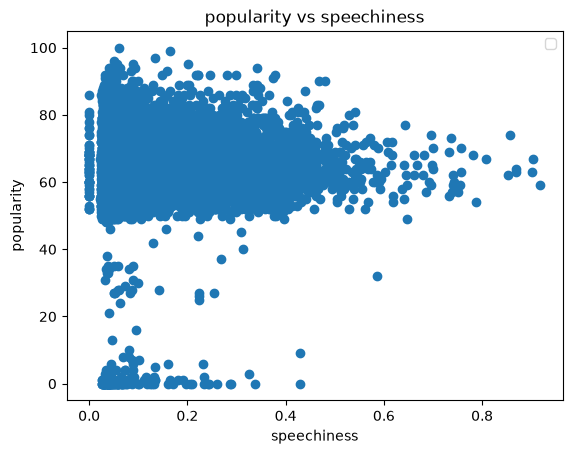

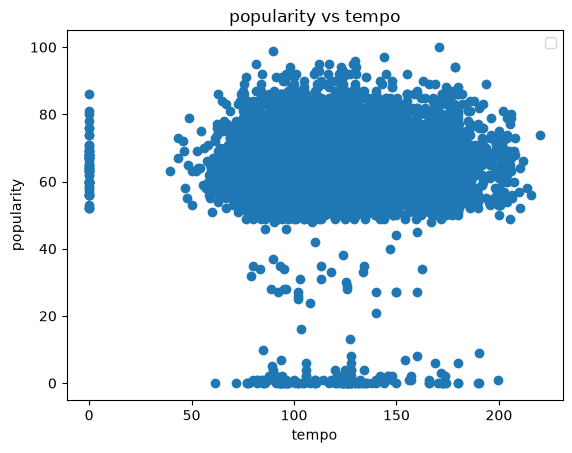

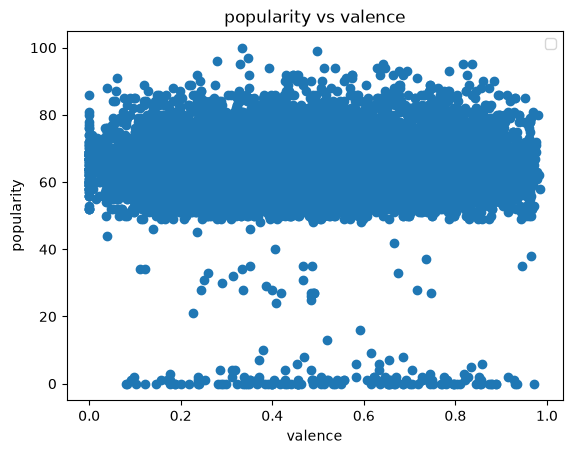

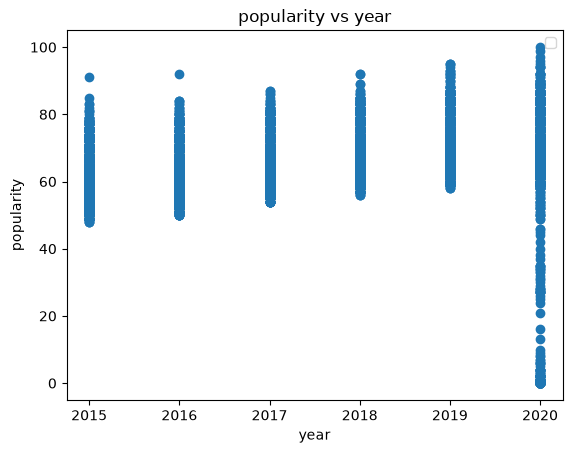

In [13]:
# Plot popularity against all other features
y_col = 'popularity'
x_columns = music_num.columns.drop('popularity')

for x_col in x_columns:
    plt.figure()
    ax = plt.gca()
    ax.scatter(music_num[x_col], music_num[y_col])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_col}")
    plt.legend()
    plt.show()


## Deep Exploratory Analyses and Big-Data Comparisons

The next sections add five detailed analyses before modeling. Each section uses PySpark for the main aggregation or filtering work, converts only small summary outputs to Pandas for plotting, and compares Spark against Pandas where the comparison is safe and meaningful on this local dataset.


In [14]:
# Shared analysis features, benchmark helpers, and plotting defaults
import time
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
MIN_ARTIST_TRACKS = 10

analysis_spark_df = (
    music_with_id_df
    .withColumn('duration_min', fn.col('duration_ms') / fn.lit(60000.0))
    .withColumn('decade', (fn.floor(fn.col('year') / 10) * 10).cast('int'))
    .withColumn(
        'clean_artist',
        fn.trim(
            fn.regexp_replace(
                fn.regexp_replace(fn.col('artists'), r'[\[\]\"\']', ''),
                r'\s+', ' '
            )
        )
    )
    .withColumn(
        'popularity_band',
        fn.when(fn.col('popularity') <= 30, 'Low (0-30)')
        .when(fn.col('popularity') <= 60, 'Medium (31-60)')
        .when(fn.col('popularity') <= 80, 'High (61-80)')
        .otherwise('Very High (81-100)')
    )
    .withColumn(
        'duration_band',
        fn.when(fn.col('duration_min') < 2, '<2 min')
        .when(fn.col('duration_min') < 3, '2-3 min')
        .when(fn.col('duration_min') < 4, '3-4 min')
        .when(fn.col('duration_min') < 5, '4-5 min')
        .otherwise('>5 min')
    )
    .cache()
)

analysis_row_count = analysis_spark_df.count()
pandas_analysis_df = raw_data.dropna(subset=numeric_columns).copy()
pandas_analysis_df['duration_min'] = pandas_analysis_df['duration_ms'] / 60000.0
pandas_analysis_df['decade'] = (np.floor(pandas_analysis_df['year'] / 10) * 10).astype(int)
pandas_analysis_df['clean_artist'] = (
    pandas_analysis_df['artists']
    .astype(str)
    .str.replace(r'[\[\]\"\']', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
pandas_analysis_df['popularity_band'] = pd.cut(
    pandas_analysis_df['popularity'],
    bins=[-0.01, 30, 60, 80, 100],
    labels=['Low (0-30)', 'Medium (31-60)', 'High (61-80)', 'Very High (81-100)']
)
pandas_analysis_df['duration_band'] = pd.cut(
    pandas_analysis_df['duration_min'],
    bins=[-np.inf, 2, 3, 4, 5, np.inf],
    labels=['<2 min', '2-3 min', '3-4 min', '4-5 min', '>5 min'],
    right=False
)

performance_records = []

def time_operation(label, spark_func, pandas_func, rows_processed, output_size, scale_note):
    spark_start = time.perf_counter()
    spark_result = spark_func()
    spark_seconds = time.perf_counter() - spark_start

    pandas_start = time.perf_counter()
    pandas_result = pandas_func()
    pandas_seconds = time.perf_counter() - pandas_start

    faster = 'Spark' if spark_seconds < pandas_seconds else 'Pandas'
    interpretation = (
        'Spark was faster in this local run.'
        if faster == 'Spark'
        else 'Pandas was faster locally; Spark overhead is expected on this dataset size.'
    )
    performance_records.append({
        'operation': label,
        'spark_seconds': round(spark_seconds, 4),
        'pandas_seconds': round(pandas_seconds, 4),
        'rows_processed': rows_processed,
        'output_size': output_size,
        'faster_locally': faster,
        'better_for_scale': 'Spark',
        'memory_scale_note': scale_note,
        'honest_interpretation': interpretation,
    })
    return spark_result, pandas_result

def show_performance_rows(operation_names):
    rows = [row for row in performance_records if row['operation'] in operation_names]
    display(pd.DataFrame(rows))

row_count_spark, row_count_pandas = time_operation(
    'row count',
    lambda: analysis_spark_df.count(),
    lambda: len(pandas_analysis_df),
    analysis_row_count,
    1,
    'Pandas is fine for this local CSV; Spark count demonstrates lazy distributed-style execution.'
)

print(f'Analysis rows available after numeric cleaning: {analysis_row_count:,}')
print(f'Pandas baseline rows: {row_count_pandas:,}')


Analysis rows available after numeric cleaning: 168,462
Pandas baseline rows: 168,462


### 1. Decade Trend Analysis

**Research question:** How have musical characteristics changed across decades? This section compares decade-level audio features and popularity to understand long-term musical shifts and the risk of modern-platform popularity bias.


,decade,song_count,avg_acousticness,avg_energy,avg_danceability,avg_loudness,avg_valence,avg_duration_min,median_duration_min,avg_popularity,median_popularity
0,1920,4441,0.831,0.241,0.577,-16.224,0.567,3.140,2.872,1.328,0.0
1,1930,8810,0.875,0.289,0.538,-13.979,0.579,3.485,3.085,2.536,0.0
2,1940,14731,0.870,0.254,0.474,-15.403,0.489,3.608,3.099,1.660,0.0
3,1950,19177,0.836,0.291,0.482,-14.693,0.487,3.678,3.084,10.242,7.0
4,1960,19917,0.621,0.416,0.497,-12.720,0.558,3.498,2.899,25.650,23.0
5,1970,19960,0.392,0.539,0.527,-11.384,0.588,4.248,3.778,35.055,33.0
6,1980,19947,0.285,0.603,0.550,-11.118,0.571,4.202,4.016,37.003,35.0
7,1990,19944,0.292,0.595,0.572,-9.845,0.550,4.153,3.999,43.627,42.0
8,2000,19917,0.258,0.659,0.576,-7.351,0.533,4.010,3.861,49.406,48.0
9,2010,19866,0.256,0.633,0.599,-7.381,0.461,3.743,3.615,59.569,59.0


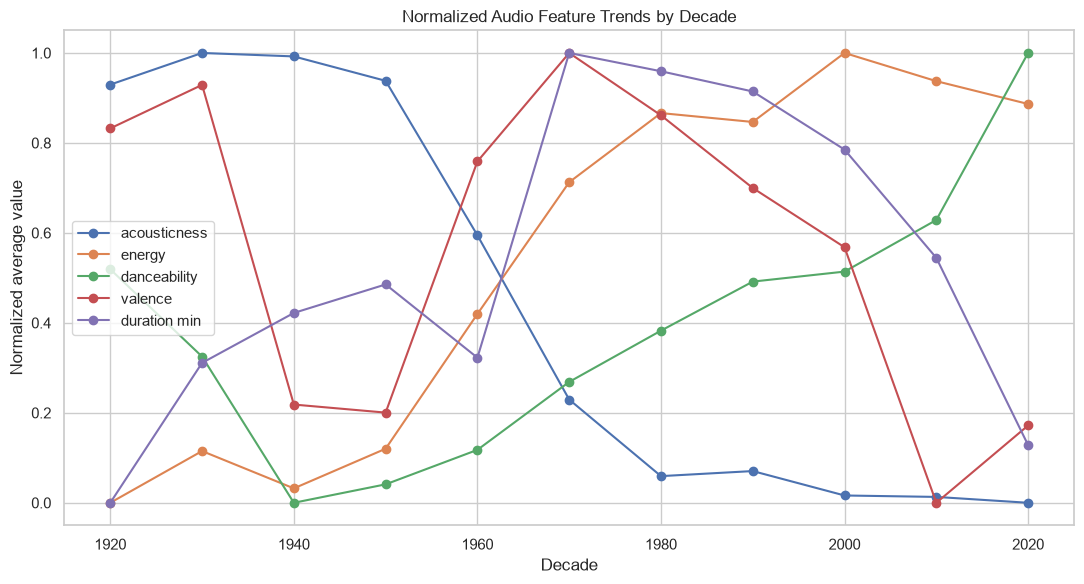

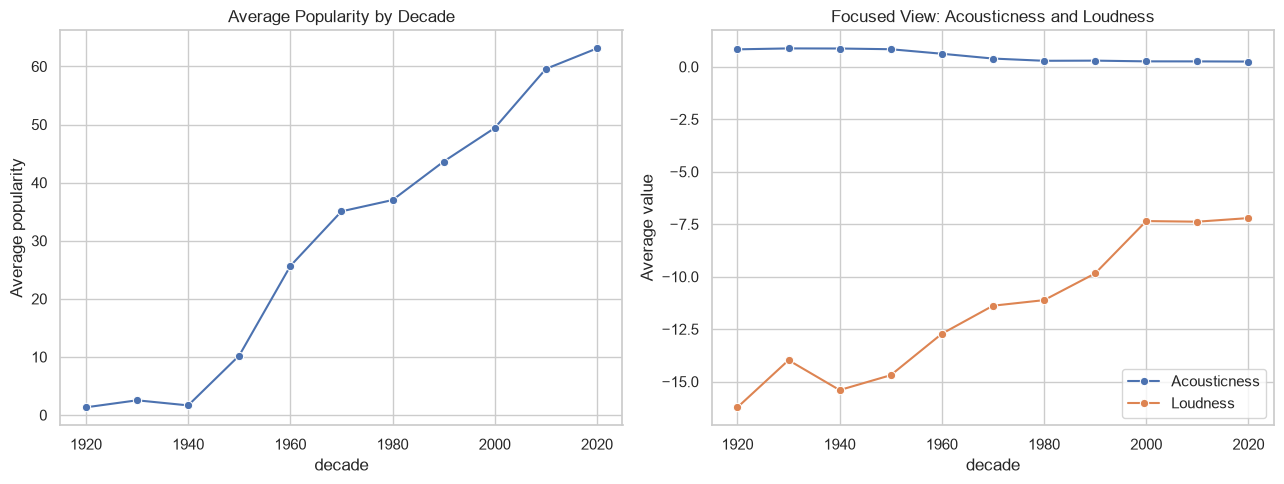

**Decade trend conclusion.** The dataset spans 1920s through 2020s. 
The largest normalized decade-level movement among the plotted features is **duration min**. 
Recent decades show much higher average popularity than early decades, but that should not be interpreted as older music being lower quality; Spotify popularity is strongly affected by current listening behavior, platform coverage, playlists, and recency. 
For business use, this section is useful for understanding era-based sound profiles, but popularity-by-decade should be treated as platform demand, not an objective historical ranking.

,operation,spark_seconds,pandas_seconds,rows_processed,output_size,faster_locally,better_for_scale,memory_scale_note,honest_interpretation
0,decade aggregation,3.1216,0.0617,168462,one row per decade,Pandas,Spark,Spark aggregation scales to larger files and c...,Pandas was faster locally; Spark overhead is e...


**Spark/Pandas note.** This decade summary is small enough that Pandas may be faster locally. Spark is still the better design for a big-data workflow because the same groupBy logic can run against larger files or distributed storage without rewriting the analysis.

In [15]:
decade_spark_result, decade_pandas_result = time_operation(
    'decade aggregation',
    lambda: (
        analysis_spark_df
        .groupBy('decade')
        .agg(
            fn.count('*').alias('song_count'),
            fn.avg('acousticness').alias('avg_acousticness'),
            fn.avg('energy').alias('avg_energy'),
            fn.avg('danceability').alias('avg_danceability'),
            fn.avg('loudness').alias('avg_loudness'),
            fn.avg('valence').alias('avg_valence'),
            fn.avg('duration_min').alias('avg_duration_min'),
            fn.expr('percentile_approx(duration_min, 0.5)').alias('median_duration_min'),
            fn.avg('popularity').alias('avg_popularity'),
            fn.expr('percentile_approx(popularity, 0.5)').alias('median_popularity')
        )
        .orderBy('decade')
        .toPandas()
    ),
    lambda: (
        pandas_analysis_df
        .groupby('decade')
        .agg(
            song_count=('id', 'count'),
            avg_acousticness=('acousticness', 'mean'),
            avg_energy=('energy', 'mean'),
            avg_danceability=('danceability', 'mean'),
            avg_loudness=('loudness', 'mean'),
            avg_valence=('valence', 'mean'),
            avg_duration_min=('duration_min', 'mean'),
            median_duration_min=('duration_min', 'median'),
            avg_popularity=('popularity', 'mean'),
            median_popularity=('popularity', 'median')
        )
        .reset_index()
        .sort_values('decade')
    ),
    analysis_row_count,
    'one row per decade',
    'Spark aggregation scales to larger files and clusters; Pandas is a convenient local baseline.'
)

decade_summary = decade_spark_result.copy()
display(decade_summary.round(3))

trend_features = ['avg_acousticness', 'avg_energy', 'avg_danceability', 'avg_valence', 'avg_duration_min']
normalized_decade = decade_summary[['decade'] + trend_features].copy()
for feature in trend_features:
    feature_min = normalized_decade[feature].min()
    feature_range = normalized_decade[feature].max() - feature_min
    normalized_decade[feature] = (normalized_decade[feature] - feature_min) / feature_range if feature_range else 0

plt.figure(figsize=(11, 6))
for feature in trend_features:
    plt.plot(normalized_decade['decade'], normalized_decade[feature], marker='o', label=feature.replace('avg_', '').replace('_', ' '))
plt.title('Normalized Audio Feature Trends by Decade')
plt.xlabel('Decade')
plt.ylabel('Normalized average value')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=decade_summary, x='decade', y='avg_popularity', marker='o', ax=axes[0])
axes[0].set_title('Average Popularity by Decade')
axes[0].set_ylabel('Average popularity')
sns.lineplot(data=decade_summary, x='decade', y='avg_acousticness', marker='o', label='Acousticness', ax=axes[1])
sns.lineplot(data=decade_summary, x='decade', y='avg_loudness', marker='o', label='Loudness', ax=axes[1])
axes[1].set_title('Focused View: Acousticness and Loudness')
axes[1].set_ylabel('Average value')
plt.tight_layout()
plt.show()

first_decade = decade_summary.iloc[0]
last_decade = decade_summary.iloc[-1]
largest_feature_change = (
    decade_summary[trend_features]
    .max()
    .sub(decade_summary[trend_features].min())
    .sort_values(ascending=False)
    .index[0]
    .replace('avg_', '')
    .replace('_', ' ')
)
display(Markdown(
    f"""**Decade trend conclusion.** The dataset spans {int(first_decade['decade'])}s through {int(last_decade['decade'])}s. 
The largest normalized decade-level movement among the plotted features is **{largest_feature_change}**. 
Recent decades show much higher average popularity than early decades, but that should not be interpreted as older music being lower quality; Spotify popularity is strongly affected by current listening behavior, platform coverage, playlists, and recency. 
For business use, this section is useful for understanding era-based sound profiles, but popularity-by-decade should be treated as platform demand, not an objective historical ranking."""
))

show_performance_rows(['decade aggregation'])
display(Markdown(
    "**Spark/Pandas note.** This decade summary is small enough that Pandas may be faster locally. Spark is still the better design for a big-data workflow because the same groupBy logic can run against larger files or distributed storage without rewriting the analysis."
))


### 2. Artist-Level Analysis

**Research question:** Which artists dominate the dataset, and are prolific artists also the most popular? This section separates catalog presence from average popularity.


Artists meeting the 10-track threshold: **3,138**

,clean_artist,track_count,avg_popularity,median_popularity,avg_duration_min,avg_energy,avg_danceability,avg_acousticness
0,Эрнест Хемингуэй,1215,0.000,0.0,1.934,0.189,0.697,0.361
1,Francisco Canaro,938,0.042,0.0,2.918,0.278,0.670,0.987
2,Эрих Мария Ремарк,781,0.000,0.0,1.921,0.200,0.692,0.128
3,Ignacio Corsini,620,0.024,0.0,2.575,0.188,0.547,0.985
4,Frank Sinatra,592,25.885,23.0,3.126,0.235,0.380,0.734
5,Bob Dylan,539,30.850,28.0,4.270,0.477,0.513,0.564
6,The Rolling Stones,512,34.512,32.0,3.827,0.720,0.524,0.295
7,Johnny Cash,502,26.106,22.0,2.669,0.451,0.621,0.700
8,The Beach Boys,491,28.084,26.0,2.483,0.534,0.503,0.396
9,Elvis Presley,488,33.490,31.0,2.602,0.426,0.496,0.742


,clean_artist,track_count,avg_popularity,median_popularity,avg_duration_min,avg_energy,avg_danceability,avg_acousticness
982,Billie Eilish,30,78.800,78.0,3.343,0.326,0.616,0.687
1203,Harry Styles,26,77.038,76.0,3.970,0.587,0.541,0.269
2258,Lewis Capaldi,14,76.857,73.0,3.408,0.433,0.586,0.660
1011,Bad Bunny,30,74.867,74.0,3.207,0.642,0.765,0.323
2624,Anuel AA,12,74.083,71.0,3.756,0.646,0.688,0.505
1332,Dua Lipa,24,73.833,77.0,3.409,0.682,0.697,0.147
3034,Lil Mosey,10,73.700,70.0,2.566,0.596,0.718,0.267
696,Juice WRLD,40,72.675,73.0,3.079,0.643,0.646,0.217
2701,Maluma,11,72.545,74.0,3.285,0.725,0.733,0.258
3028,Jeremy Zucker,10,72.400,74.0,3.089,0.276,0.725,0.698


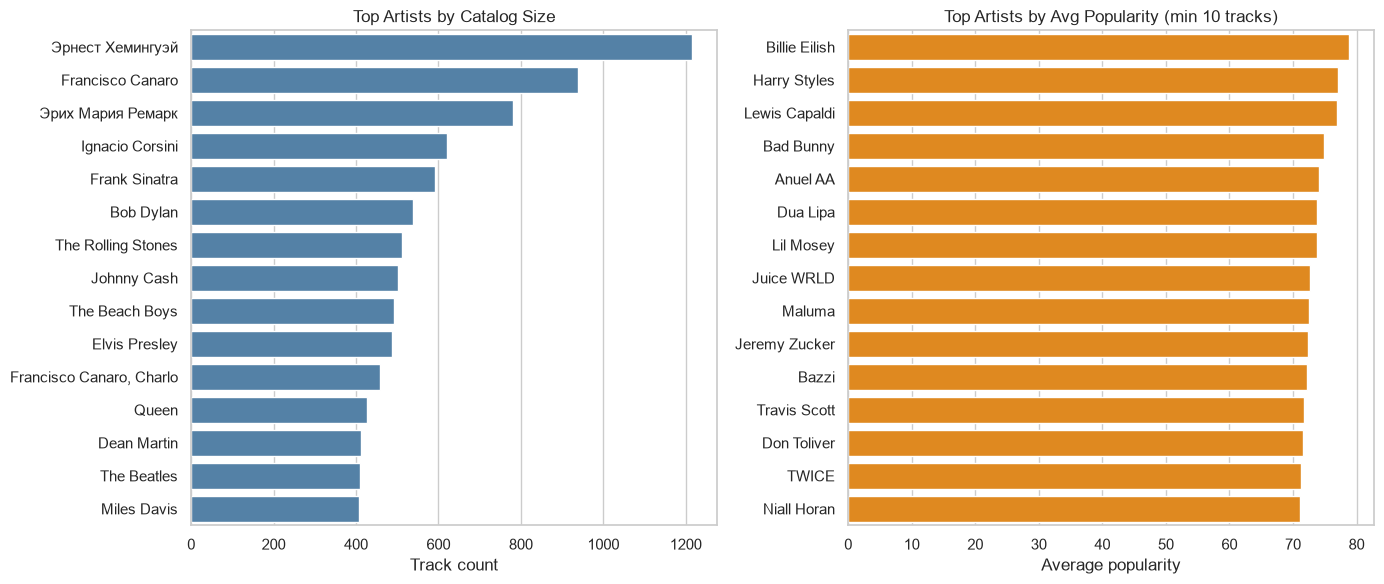

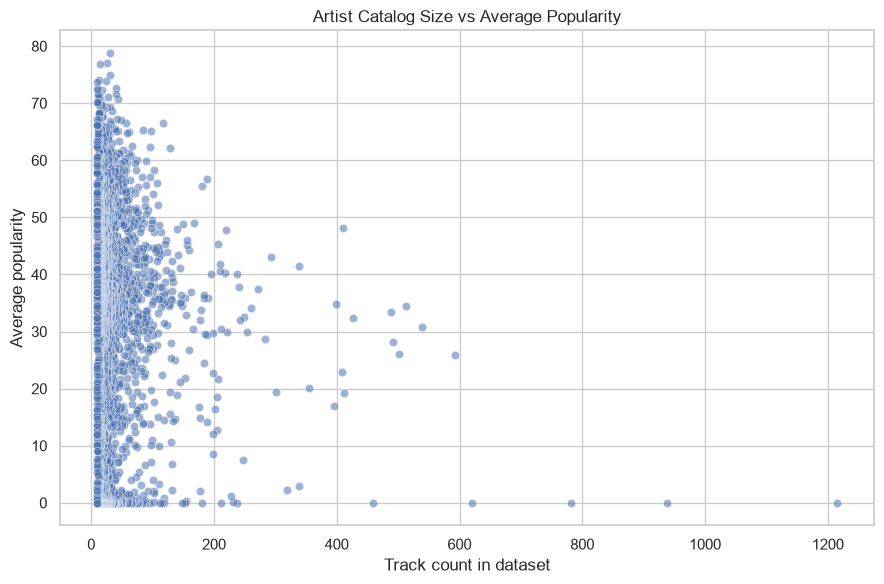

**Artist-level conclusion.** Among artists with at least 10 tracks, catalog size and average popularity have a correlation of **-0.043**. 
That means a large catalog in this dataset does not automatically guarantee high average popularity. 
For a professor, this is a useful example of why count-based dominance and performance-based popularity are different measures. 
For business use, the result suggests two different actions: catalog-heavy artists may matter for library coverage, while high-average-popularity artists are stronger candidates for playlisting, promotion, or recommendation seed examples.

,operation,spark_seconds,pandas_seconds,rows_processed,output_size,faster_locally,better_for_scale,memory_scale_note,honest_interpretation
0,artist aggregation,3.7768,0.2073,168462,artists with at least 10 tracks,Pandas,Spark,Artist grouping can grow quickly with larger c...,Pandas was faster locally; Spark overhead is e...


**Spark/Pandas note.** Artist aggregation is a high-cardinality grouping task. Pandas can handle this CSV locally, but Spark is the safer pattern as catalog size grows or when artist-level summaries need to be recomputed repeatedly.

In [16]:
artist_spark_result, artist_pandas_result = time_operation(
    'artist aggregation',
    lambda: (
        analysis_spark_df
        .groupBy('clean_artist')
        .agg(
            fn.count('*').alias('track_count'),
            fn.avg('popularity').alias('avg_popularity'),
            fn.expr('percentile_approx(popularity, 0.5)').alias('median_popularity'),
            fn.avg('duration_min').alias('avg_duration_min'),
            fn.avg('energy').alias('avg_energy'),
            fn.avg('danceability').alias('avg_danceability'),
            fn.avg('acousticness').alias('avg_acousticness')
        )
        .where(fn.col('track_count') >= MIN_ARTIST_TRACKS)
        .orderBy(fn.desc('track_count'))
        .toPandas()
    ),
    lambda: (
        pandas_analysis_df
        .groupby('clean_artist')
        .agg(
            track_count=('id', 'count'),
            avg_popularity=('popularity', 'mean'),
            median_popularity=('popularity', 'median'),
            avg_duration_min=('duration_min', 'mean'),
            avg_energy=('energy', 'mean'),
            avg_danceability=('danceability', 'mean'),
            avg_acousticness=('acousticness', 'mean')
        )
        .query('track_count >= @MIN_ARTIST_TRACKS')
        .reset_index()
        .sort_values('track_count', ascending=False)
    ),
    analysis_row_count,
    f'artists with at least {MIN_ARTIST_TRACKS} tracks',
    'Artist grouping can grow quickly with larger catalogs; Spark handles high-cardinality groupBy operations more safely.'
)

artist_summary = artist_spark_result.copy()
top_catalog_artists = artist_summary.sort_values('track_count', ascending=False).head(15)
top_popular_artists = artist_summary.sort_values('avg_popularity', ascending=False).head(15)

display(Markdown(f'Artists meeting the {MIN_ARTIST_TRACKS}-track threshold: **{len(artist_summary):,}**'))
display(top_catalog_artists.round(3))
display(top_popular_artists.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_catalog_artists, y='clean_artist', x='track_count', ax=axes[0], color='steelblue')
axes[0].set_title('Top Artists by Catalog Size')
axes[0].set_xlabel('Track count')
axes[0].set_ylabel('')
sns.barplot(data=top_popular_artists, y='clean_artist', x='avg_popularity', ax=axes[1], color='darkorange')
axes[1].set_title(f'Top Artists by Avg Popularity (min {MIN_ARTIST_TRACKS} tracks)')
axes[1].set_xlabel('Average popularity')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=artist_summary, x='track_count', y='avg_popularity', alpha=0.55)
plt.title('Artist Catalog Size vs Average Popularity')
plt.xlabel('Track count in dataset')
plt.ylabel('Average popularity')
plt.tight_layout()
plt.show()

catalog_popularity_corr = artist_summary[['track_count', 'avg_popularity']].corr().iloc[0, 1]
display(Markdown(
    f"""**Artist-level conclusion.** Among artists with at least {MIN_ARTIST_TRACKS} tracks, catalog size and average popularity have a correlation of **{catalog_popularity_corr:.3f}**. 
That means a large catalog in this dataset does not automatically guarantee high average popularity. 
For a professor, this is a useful example of why count-based dominance and performance-based popularity are different measures. 
For business use, the result suggests two different actions: catalog-heavy artists may matter for library coverage, while high-average-popularity artists are stronger candidates for playlisting, promotion, or recommendation seed examples."""
))

show_performance_rows(['artist aggregation'])
display(Markdown(
    "**Spark/Pandas note.** Artist aggregation is a high-cardinality grouping task. Pandas can handle this CSV locally, but Spark is the safer pattern as catalog size grows or when artist-level summaries need to be recomputed repeatedly."
))


### 3. Popularity Segment Profiling

**Research question:** What audio characteristics distinguish low-, medium-, high-, and very-high-popularity songs? This is association analysis, not proof of causation.


,popularity_band,song_count,avg_acousticness,avg_danceability,avg_energy,avg_loudness,avg_valence,avg_tempo,avg_duration_min,median_popularity
2,Low (0-30),75532,0.711,0.504,0.359,-13.871,0.533,113.165,3.684,9.0
0,Medium (31-60),77349,0.320,0.558,0.593,-9.573,0.542,120.177,4.054,44.0
1,High (61-80),15124,0.262,0.617,0.620,-7.749,0.499,120.467,3.704,66.0
3,Very High (81-100),457,0.243,0.696,0.624,-6.291,0.507,120.205,3.402,83.0


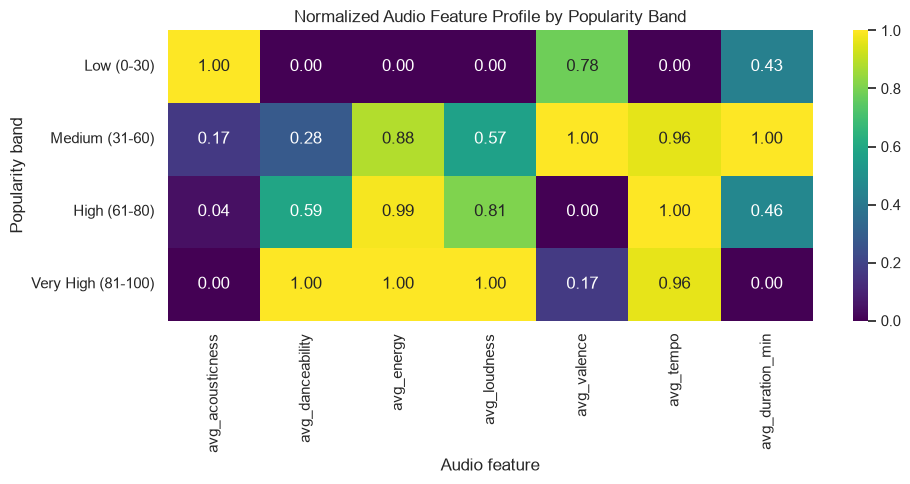

,hit_segment,song_count,avg_danceability,avg_energy,avg_loudness,avg_acousticness,avg_duration_min,avg_tempo
0,Top 10% popularity,17270,0.618,0.621,-7.715,0.262,3.713,120.394
1,Remaining 90%,151192,0.530,0.476,-11.740,0.516,3.871,116.678


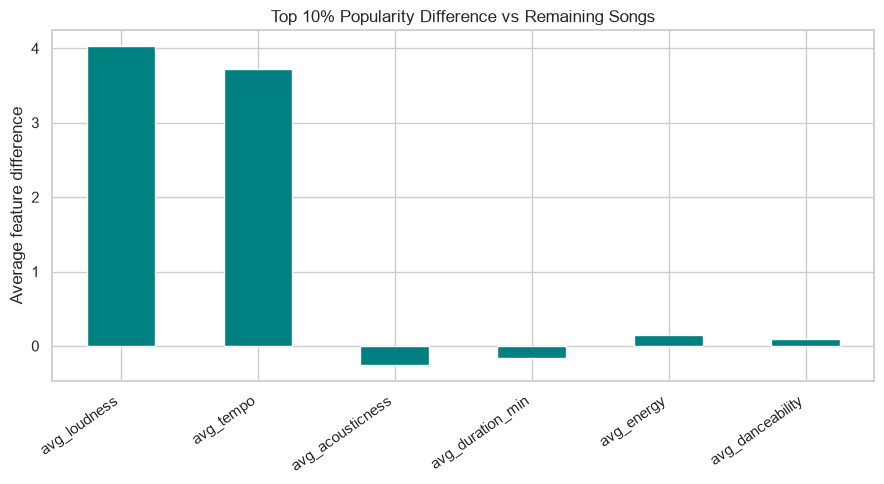

**Popularity segment conclusion.** The largest top-hit versus non-hit average difference is **loudness**. 
These patterns are useful for describing what popular songs tend to sound like in this dataset, but they are not causal proof. 
Popularity is affected by many missing variables: artist fame, playlist placement, marketing, release timing, social trends, and Spotify platform behavior. 
For business use, this section can support playlist or catalog profiling, but it should not be used alone to predict commercial success.

,operation,spark_seconds,pandas_seconds,rows_processed,output_size,faster_locally,better_for_scale,memory_scale_note,honest_interpretation
0,popularity-band aggregation,0.8427,0.0399,168462,four popularity bands,Pandas,Spark,Banding is cheap locally; Spark makes the tran...,Pandas was faster locally; Spark overhead is e...


**Spark/Pandas note.** Popularity-band profiling is easy in Pandas here, but Spark keeps the segmentation logic close to the full-data pipeline and makes it reusable for larger feature tables or scheduled refreshes.

In [17]:
popularity_spark_result, popularity_pandas_result = time_operation(
    'popularity-band aggregation',
    lambda: (
        analysis_spark_df
        .groupBy('popularity_band')
        .agg(
            fn.count('*').alias('song_count'),
            fn.avg('acousticness').alias('avg_acousticness'),
            fn.avg('danceability').alias('avg_danceability'),
            fn.avg('energy').alias('avg_energy'),
            fn.avg('loudness').alias('avg_loudness'),
            fn.avg('valence').alias('avg_valence'),
            fn.avg('tempo').alias('avg_tempo'),
            fn.avg('duration_min').alias('avg_duration_min'),
            fn.expr('percentile_approx(popularity, 0.5)').alias('median_popularity')
        )
        .toPandas()
    ),
    lambda: (
        pandas_analysis_df
        .groupby('popularity_band', observed=False)
        .agg(
            song_count=('id', 'count'),
            avg_acousticness=('acousticness', 'mean'),
            avg_danceability=('danceability', 'mean'),
            avg_energy=('energy', 'mean'),
            avg_loudness=('loudness', 'mean'),
            avg_valence=('valence', 'mean'),
            avg_tempo=('tempo', 'mean'),
            avg_duration_min=('duration_min', 'mean'),
            median_popularity=('popularity', 'median')
        )
        .reset_index()
    ),
    analysis_row_count,
    'four popularity bands',
    'Banding is cheap locally; Spark makes the transformation reusable for larger datasets and downstream modeling.'
)

band_order = ['Low (0-30)', 'Medium (31-60)', 'High (61-80)', 'Very High (81-100)']
popularity_summary = popularity_spark_result.copy()
popularity_summary['popularity_band'] = pd.Categorical(popularity_summary['popularity_band'], categories=band_order, ordered=True)
popularity_summary = popularity_summary.sort_values('popularity_band')
display(popularity_summary.round(3))

feature_columns_for_heatmap = [
    'avg_acousticness', 'avg_danceability', 'avg_energy', 'avg_loudness',
    'avg_valence', 'avg_tempo', 'avg_duration_min'
]
heatmap_data = popularity_summary.set_index('popularity_band')[feature_columns_for_heatmap]
normalized_heatmap = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(10, 5))
sns.heatmap(normalized_heatmap, annot=True, fmt='.2f', cmap='viridis')
plt.title('Normalized Audio Feature Profile by Popularity Band')
plt.xlabel('Audio feature')
plt.ylabel('Popularity band')
plt.tight_layout()
plt.show()

top_hit_threshold = pandas_analysis_df['popularity'].quantile(0.90)
top_hit_spark = (
    analysis_spark_df
    .withColumn('hit_segment', fn.when(fn.col('popularity') >= float(top_hit_threshold), 'Top 10% popularity').otherwise('Remaining 90%'))
    .groupBy('hit_segment')
    .agg(
        fn.count('*').alias('song_count'),
        fn.avg('danceability').alias('avg_danceability'),
        fn.avg('energy').alias('avg_energy'),
        fn.avg('loudness').alias('avg_loudness'),
        fn.avg('acousticness').alias('avg_acousticness'),
        fn.avg('duration_min').alias('avg_duration_min'),
        fn.avg('tempo').alias('avg_tempo')
    )
    .toPandas()
)
display(top_hit_spark.round(3))

top_vs_rest = top_hit_spark.set_index('hit_segment')
if {'Top 10% popularity', 'Remaining 90%'}.issubset(top_vs_rest.index):
    differences = (
        top_vs_rest.loc['Top 10% popularity', ['avg_danceability', 'avg_energy', 'avg_loudness', 'avg_acousticness', 'avg_duration_min', 'avg_tempo']]
        - top_vs_rest.loc['Remaining 90%', ['avg_danceability', 'avg_energy', 'avg_loudness', 'avg_acousticness', 'avg_duration_min', 'avg_tempo']]
    ).sort_values(key=lambda values: values.abs(), ascending=False)
else:
    differences = pd.Series(dtype=float)

plt.figure(figsize=(9, 5))
differences.plot(kind='bar', color='teal')
plt.title('Top 10% Popularity Difference vs Remaining Songs')
plt.ylabel('Average feature difference')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

largest_popularity_difference = differences.index[0].replace('avg_', '').replace('_', ' ') if len(differences) else 'no stable feature'
display(Markdown(
    f"""**Popularity segment conclusion.** The largest top-hit versus non-hit average difference is **{largest_popularity_difference}**. 
These patterns are useful for describing what popular songs tend to sound like in this dataset, but they are not causal proof. 
Popularity is affected by many missing variables: artist fame, playlist placement, marketing, release timing, social trends, and Spotify platform behavior. 
For business use, this section can support playlist or catalog profiling, but it should not be used alone to predict commercial success."""
))

show_performance_rows(['popularity-band aggregation'])
display(Markdown(
    "**Spark/Pandas note.** Popularity-band profiling is easy in Pandas here, but Spark keeps the segmentation logic close to the full-data pipeline and makes it reusable for larger feature tables or scheduled refreshes."
))


### 4. Outlier and Extreme Song Analysis

**Research question:** Which songs are unusual, and are those records valid musical edge cases or possible data-quality problems?


,feature,q1,median,q3,iqr,low_threshold,high_threshold
0,duration_min,2.849,3.467,4.347,1.497,0.603,6.593
1,tempo,93.622,114.529,134.979,41.357,31.587,197.014
2,loudness,-14.429,-10.533,-7.201,7.228,-25.271,3.641
3,energy,0.260,0.480,0.703,0.443,-0.404,1.367
4,danceability,0.416,0.546,0.665,0.249,0.042,1.038
5,popularity,12.000,33.000,48.000,36.000,-42.000,102.000


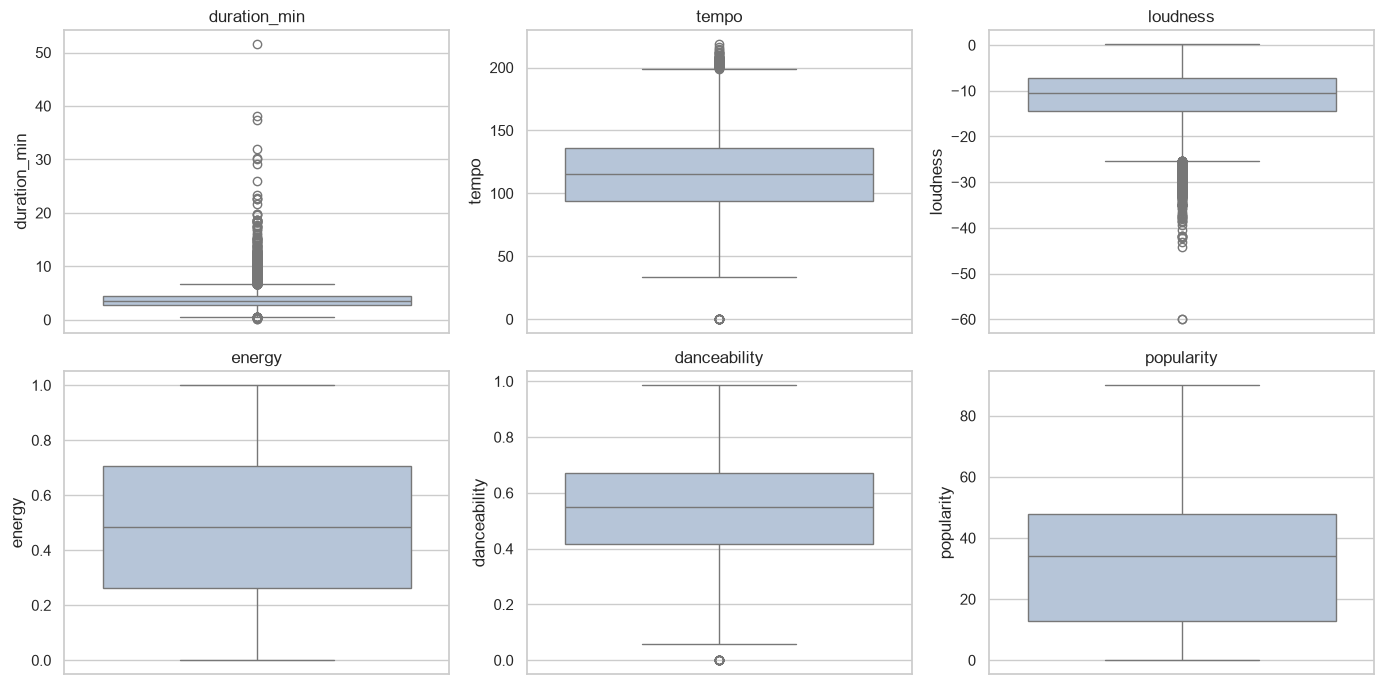

**Highest duration examples**

,id,name,clean_artist,year,popularity,duration_min
0,7foc25ig7dibxvULPU2kBG,Brown Noise - 90 Minutes,Sound Dreamer,2013.0,50.0,90.058333
1,605JTCltCe1IcqrGXQ294K,Brown Noise for Sleep,Sounds for Life,2009.0,42.0,71.167233
2,7dYf0CsWHDLvlP6HJPs3zO,Midnight Thunderstorm Part 2,"Lightning, Thunder and Rain Storm",2009.0,44.0,71.156783
3,1saXdvEAafdRzUphXBzSHg,Ocean Waves for Sleep,Ocean Waves For Sleep,2010.0,55.0,68.670967
4,2QfFLpSGF1T1pY6tq4kD7Z,Ocean Waves Sounds,Ocean Sounds,2010.0,44.0,68.670967


**Lowest duration examples**

,id,name,clean_artist,year,popularity,duration_min
0,0hr9kRUi2X4MXc72A4VxG4,Pause Track,Sarah Vaughan,1949.0,0.0,0.085133
1,3IcXTeq9O2dpsSXsDj9naH,Pause Track - Live,Benny Goodman,1938.0,0.0,0.099850
2,523qs4UcGlQ6ycdha1VGqs,Pause Track - Live,Benny Goodman,1938.0,0.0,0.106033
3,3lRVIn6D6EUbvkOgPZAU1H,Pause Track,Sarah Vaughan,1949.0,0.0,0.107783
4,0MMpXuAkKfU4poBGLwHXUI,"Rhapsody on a Theme of Paganini, Op. 43: Intro...","Sergei Rachmaninoff, Arthur Rubinstein, Fritz ...",1953.0,0.0,0.147550


**Highest tempo examples**

...

**Lowest popularity examples**

,id,name,clean_artist,year,popularity,popularity
0,76WMWYa1iqRTHZotPuuEuc,Catalina,ROSALÍA,2020.0,0.0,0.0
1,6U7X6rtxqIxdh2F9ScqIOI,La Diana - Remasterizado,Francisco Canaro,1924.0,0.0,0.0
2,4RGPyKhPVpW40WkqGF01j8,Часть 46.2 - Фиеста,Эрнест Хемингуэй,1926.0,0.0,0.0
3,6chy6jsXy1CVdTeNTqhQkC,Caricias - Remasterizado,Francisco Canaro,1924.0,0.0,0.0
4,6cgmaFVNKBRiPuN6YKpJFu,Heaven,Bryan Adams,2020.0,0.0,0.0


**Outlier conclusion.** The IQR high threshold for duration is about **6.59 minutes**, and **9,491** songs exceed it. 
Many outliers are likely valid musical edge cases, such as live recordings, classical pieces, spoken-word tracks, or very short interludes, but extreme values should still be inspected before modeling decisions. 
Outliers can influence regression error, cluster centers, and recommendation distance calculations, so the responsible approach is not blind deletion; it is inspection, scaling, and robust interpretation.

,operation,spark_seconds,pandas_seconds,rows_processed,output_size,faster_locally,better_for_scale,memory_scale_note,honest_interpretation
0,outlier quantile summary,2.1553,0.0341,168462,6 feature summaries,Pandas,Spark,Spark approximate quantiles avoid collecting f...,Pandas was faster locally; Spark overhead is e...


**Spark/Pandas note.** Pandas exact quantiles are convenient locally. Spark approximate quantiles are the more scalable option because they avoid collecting complete feature columns to the driver.

In [18]:
outlier_features = ['duration_min', 'tempo', 'loudness', 'energy', 'danceability', 'popularity']

def spark_outlier_summary():
    rows = []
    for feature in outlier_features:
        q1, median, q3 = analysis_spark_df.approxQuantile(feature, [0.25, 0.5, 0.75], 0.01)
        iqr = q3 - q1
        rows.append({
            'feature': feature,
            'q1': q1,
            'median': median,
            'q3': q3,
            'iqr': iqr,
            'low_threshold': q1 - 1.5 * iqr,
            'high_threshold': q3 + 1.5 * iqr,
        })
    return pd.DataFrame(rows)

def pandas_outlier_summary():
    rows = []
    for feature in outlier_features:
        q1, median, q3 = pandas_analysis_df[feature].quantile([0.25, 0.5, 0.75])
        iqr = q3 - q1
        rows.append({
            'feature': feature,
            'q1': q1,
            'median': median,
            'q3': q3,
            'iqr': iqr,
            'low_threshold': q1 - 1.5 * iqr,
            'high_threshold': q3 + 1.5 * iqr,
        })
    return pd.DataFrame(rows)

outlier_spark_result, outlier_pandas_result = time_operation(
    'outlier quantile summary',
    spark_outlier_summary,
    pandas_outlier_summary,
    analysis_row_count,
    f'{len(outlier_features)} feature summaries',
    'Spark approximate quantiles avoid collecting full columns and are suitable for larger-than-memory data.'
)

outlier_summary = outlier_spark_result.copy()
display(outlier_summary.round(3))

boxplot_sample = pandas_analysis_df[outlier_features].sample(
    n=min(12000, len(pandas_analysis_df)),
    random_state=RANDOM_SEED
)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for axis, feature in zip(axes.ravel(), outlier_features):
    sns.boxplot(y=boxplot_sample[feature], ax=axis, color='lightsteelblue')
    axis.set_title(feature)
plt.tight_layout()
plt.show()

def top_bottom_table(feature, label, limit=5):
    high_rows = (
        analysis_spark_df
        .select('id', 'name', 'clean_artist', 'year', 'popularity', feature)
        .orderBy(fn.desc(feature))
        .limit(limit)
        .toPandas()
    )
    low_rows = (
        analysis_spark_df
        .select('id', 'name', 'clean_artist', 'year', 'popularity', feature)
        .orderBy(fn.asc(feature))
        .limit(limit)
        .toPandas()
    )
    display(Markdown(f'**Highest {label} examples**'))
    display(high_rows)
    display(Markdown(f'**Lowest {label} examples**'))
    display(low_rows)

top_bottom_table('duration_min', 'duration')
top_bottom_table('tempo', 'tempo')
top_bottom_table('loudness', 'loudness')
top_bottom_table('popularity', 'popularity')

duration_high_threshold = outlier_summary.loc[outlier_summary['feature'] == 'duration_min', 'high_threshold'].iloc[0]
very_long_count = analysis_spark_df.where(fn.col('duration_min') > float(duration_high_threshold)).count()
display(Markdown(
    f"""**Outlier conclusion.** The IQR high threshold for duration is about **{duration_high_threshold:.2f} minutes**, and **{very_long_count:,}** songs exceed it. 
Many outliers are likely valid musical edge cases, such as live recordings, classical pieces, spoken-word tracks, or very short interludes, but extreme values should still be inspected before modeling decisions. 
Outliers can influence regression error, cluster centers, and recommendation distance calculations, so the responsible approach is not blind deletion; it is inspection, scaling, and robust interpretation."""
))

show_performance_rows(['outlier quantile summary'])
display(Markdown(
    "**Spark/Pandas note.** Pandas exact quantiles are convenient locally. Spark approximate quantiles are the more scalable option because they avoid collecting complete feature columns to the driver."
))


### 5. Song Duration Evolution

**Research question:** Have songs become shorter or longer over time? This section compares averages, medians, and duration-band shares so long-song outliers do not dominate the story.


,decade,song_count,avg_duration_min,median_duration_min
0,1920,4441,3.140,2.872
1,1930,8810,3.485,3.085
2,1940,14731,3.608,3.099
3,1950,19177,3.678,3.084
4,1960,19917,3.498,2.899
5,1970,19960,4.248,3.778
6,1980,19947,4.202,4.016
7,1990,19944,4.153,3.999
8,2000,19917,4.010,3.861
9,2010,19866,3.743,3.615


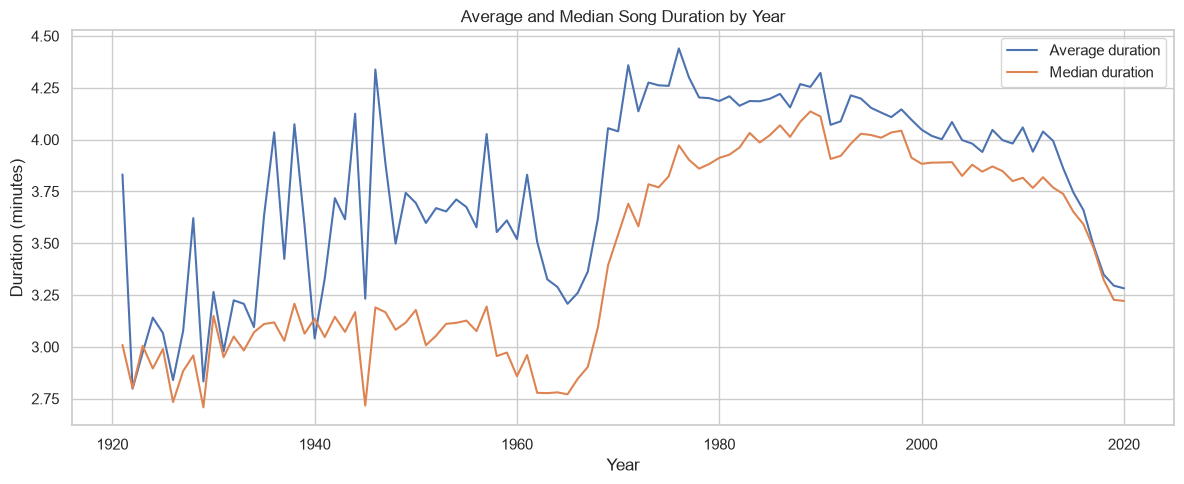

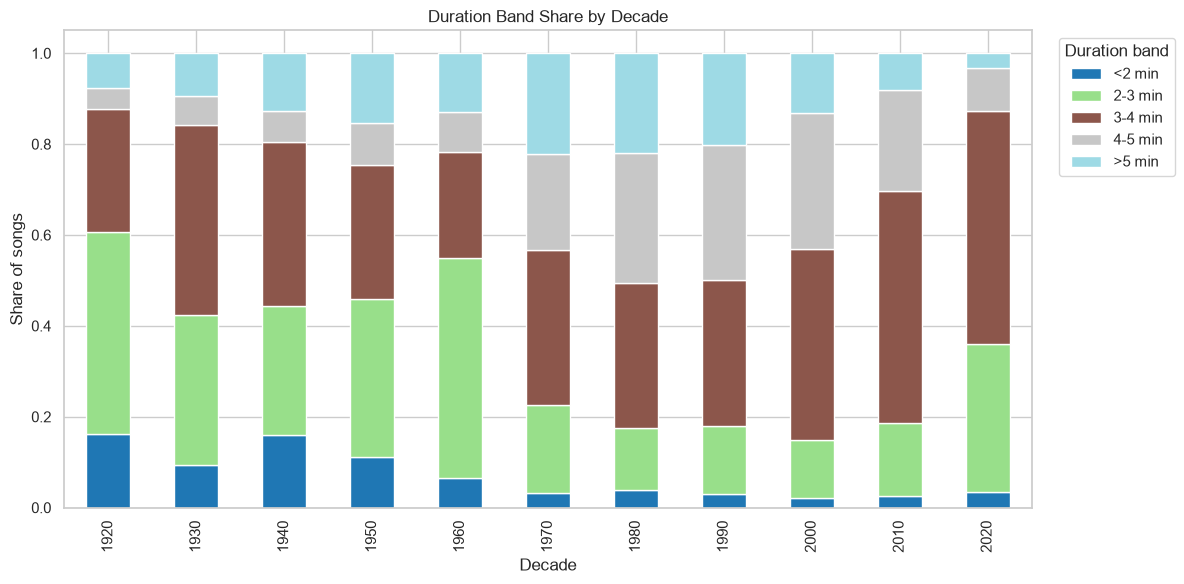

**Duration evolution conclusion.** The shortest average-duration decade is the **1920s** at about **3.14 minutes**, while the longest is the **1970s** at about **4.25 minutes**. 
Average and median duration should be read together because long tracks can pull the average upward. 
For business use, duration-band changes matter for playlist design, radio-style formatting, listener attention, and streaming-era sequencing decisions.

,operation,spark_seconds,pandas_seconds,rows_processed,output_size,faster_locally,better_for_scale,memory_scale_note,honest_interpretation
0,duration-band aggregation,0.531,0.0276,168462,duration bands by decade,Pandas,Spark,Duration banding is local-friendly here; Spark...,Pandas was faster locally; Spark overhead is e...


**Spark/Pandas note.** Duration-band aggregation is simple locally, but Spark keeps the operation aligned with the big-data pipeline and avoids driver-memory dependence on larger datasets.

In [19]:
duration_spark_result, duration_pandas_result = time_operation(
    'duration-band aggregation',
    lambda: (
        analysis_spark_df
        .groupBy('decade', 'duration_band')
        .agg(fn.count('*').alias('song_count'))
        .orderBy('decade', 'duration_band')
        .toPandas()
    ),
    lambda: (
        pandas_analysis_df
        .groupby(['decade', 'duration_band'], observed=False)
        .agg(song_count=('id', 'count'))
        .reset_index()
        .sort_values(['decade', 'duration_band'])
    ),
    analysis_row_count,
    'duration bands by decade',
    'Duration banding is local-friendly here; Spark makes the same bucketing scalable and reusable.'
)

duration_by_year = (
    analysis_spark_df
    .groupBy('year')
    .agg(
        fn.count('*').alias('song_count'),
        fn.avg('duration_min').alias('avg_duration_min'),
        fn.expr('percentile_approx(duration_min, 0.5)').alias('median_duration_min')
    )
    .orderBy('year')
    .toPandas()
)
duration_by_decade = (
    analysis_spark_df
    .groupBy('decade')
    .agg(
        fn.count('*').alias('song_count'),
        fn.avg('duration_min').alias('avg_duration_min'),
        fn.expr('percentile_approx(duration_min, 0.5)').alias('median_duration_min')
    )
    .orderBy('decade')
    .toPandas()
)

display(duration_by_decade.round(3))

plt.figure(figsize=(12, 5))
sns.lineplot(data=duration_by_year, x='year', y='avg_duration_min', label='Average duration')
sns.lineplot(data=duration_by_year, x='year', y='median_duration_min', label='Median duration')
plt.title('Average and Median Song Duration by Year')
plt.xlabel('Year')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

duration_band_summary = duration_spark_result.copy()
duration_band_summary['duration_band'] = pd.Categorical(
    duration_band_summary['duration_band'],
    categories=['<2 min', '2-3 min', '3-4 min', '4-5 min', '>5 min'],
    ordered=True
)
duration_band_summary = duration_band_summary.sort_values(['decade', 'duration_band'])
duration_band_pivot = duration_band_summary.pivot_table(
    index='decade',
    columns='duration_band',
    values='song_count',
    aggfunc='sum',
    fill_value=0,
    observed=False
)
duration_band_share = duration_band_pivot.div(duration_band_pivot.sum(axis=1), axis=0)

duration_band_share.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Duration Band Share by Decade')
plt.xlabel('Decade')
plt.ylabel('Share of songs')
plt.legend(title='Duration band', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

shortest_decade = duration_by_decade.sort_values('avg_duration_min').iloc[0]
longest_decade = duration_by_decade.sort_values('avg_duration_min', ascending=False).iloc[0]
latest_decade_duration = duration_by_decade.sort_values('decade').iloc[-1]
display(Markdown(
    f"""**Duration evolution conclusion.** The shortest average-duration decade is the **{int(shortest_decade['decade'])}s** at about **{shortest_decade['avg_duration_min']:.2f} minutes**, while the longest is the **{int(longest_decade['decade'])}s** at about **{longest_decade['avg_duration_min']:.2f} minutes**. 
Average and median duration should be read together because long tracks can pull the average upward. 
For business use, duration-band changes matter for playlist design, radio-style formatting, listener attention, and streaming-era sequencing decisions."""
))

show_performance_rows(['duration-band aggregation'])
display(Markdown(
    "**Spark/Pandas note.** Duration-band aggregation is simple locally, but Spark keeps the operation aligned with the big-data pipeline and avoids driver-memory dependence on larger datasets."
))


##Data Preparation for Linear Regression

In [20]:
# Assemble and scale regression features with a Spark ML pipeline
regression_features = ['danceability', 'energy', 'loudness', 'explicit', 'key']
regression_feature_pipe = Pipeline(stages=[
    VectorAssembler(inputCols=regression_features, outputCol='regression_features', handleInvalid='skip'),
    StandardScaler(withMean=True, withStd=True, inputCol='regression_features', outputCol='features'),
])

regression_feature_model = regression_feature_pipe.fit(music_df)
music_df_xformed = regression_feature_model.transform(music_df).cache()

train, test, val = music_df_xformed.randomSplit([0.7, 0.2, 0.1], seed=RANDOM_SEED)
print(f'Train rows: {train.count():,}, test rows: {test.count():,}, validation rows: {val.count():,}')


Train rows: 117,861, test rows: 33,703, validation rows: 16,898


## Linear Regression - Model Training and Evaluation

In [21]:
# Linear Regression baseline
linear_reg = LinearRegression(featuresCol='features', labelCol='popularity')
model1 = linear_reg.fit(train)
model1_output = model1.transform(train)
model1_evaluator = RegressionEvaluator(predictionCol='prediction', metricName='mse', labelCol='popularity')

print('Coefficients: ' + str(model1.coefficients))
print('Intercept: ' + str(model1.intercept))
print('RMSE of Linear Regression Model: %f' % model1.summary.rootMeanSquaredError)

lr_mse = model1_evaluator.evaluate(model1.transform(test))
print('Linear Regression MSE:', lr_mse)
print('Training MSE value:', model1_evaluator.evaluate(model1_output))
print('Testing MSE value:', lr_mse)

model1_output.select('prediction', 'popularity', 'features').show(5)


Coefficients: [1.4274870359445866,7.1371536265253726,3.6253695347632244,2.6780707464438755,-0.11078057542444593]
Intercept: 31.723753367363344
RMSE of Linear Regression Model: 18.226444


Linear Regression MSE: 331.37683883263537


Training MSE value: 332.2032734435935
Testing MSE value: 331.37683883263537


+------------------+----------+--------------------+
|        prediction|popularity|            features|
+------------------+----------+--------------------+
| 16.91356467614879|      63.0|[-1.8845586746802...|
|33.738727743786555|      63.0|[-2.1134075060700...|
|11.867256428521898|      63.0|[-3.0860150394767...|
| 40.61037102412756|      39.0|[-0.9920482322599...|
|  45.1341787020514|      49.0|[-1.2666668299277...|
+------------------+----------+--------------------+
only showing top 5 rows



##Random Forest - Model Training and Evaluation

In [22]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorIndexer
from pyspark.ml.evaluation import RegressionEvaluator

# Feature indexing
feature_indexer = VectorIndexer(inputCol="features", outputCol="indexedFeatures", maxCategories=4).fit(music_df_xformed)

# Initialize Random Forest
rf = RandomForestRegressor(featuresCol="indexedFeatures", labelCol="popularity")
pipeline = Pipeline(stages=[feature_indexer, rf])

# Train Random Forest model
rf_model = pipeline.fit(train)
predictions = rf_model.transform(test)

# Evaluate using MSE
evaluator = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="mse")
rf_mse = evaluator.evaluate(predictions)
print("MSE on test data = %g" % rf_mse)

# Evaluate Random Forest on the test set
rf_mse = evaluator.evaluate(predictions)  # Store Random Forest MSE
print("Random Forest MSE:", rf_mse)


# Show sample predictions
predictions.select("prediction", "popularity", "features").show(5)

# Extract the trained Random Forest model
rf_trained_model = rf_model.stages[1]
print(rf_trained_model)


MSE on test data = 298.34


Random Forest MSE: 298.3401689936427


+-----------------+----------+--------------------+
|       prediction|popularity|            features|
+-----------------+----------+--------------------+
|39.06291481605933|      45.0|[-1.4554671158243...|
|39.39091625554965|      35.0|[-2.1362923892090...|
|35.68156759135675|      44.0|[-1.8330676876175...|
|34.05550849075006|      31.0|[-1.8502313499717...|
| 44.9789397330591|      40.0|[-1.2323395052192...|
+-----------------+----------+--------------------+
only showing top 5 rows

RandomForestRegressionModel: uid=RandomForestRegressor_c70413a8cc7b, numTrees=20, numFeatures=5


##Hyperparameter Tuning for Random Forest (Optional)

In [23]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
enable_grid_search = ENABLE_GRID_SEARCH
if enable_grid_search:
    # Hyperparameter tuning for Random Forest
    param_grid = ParamGridBuilder() \
        .addGrid(rf.numTrees, [10, 30, 50]) \
        .addGrid(rf.maxDepth, [5, 15, 25]) \
        .build()

    evaluator = RegressionEvaluator(labelCol='popularity', predictionCol='prediction', metricName='rmse')
    cv = CrossValidator(estimator=pipeline, estimatorParamMaps=param_grid, evaluator=evaluator, numFolds=2)

    # Cross-validation model
    cv_model = cv.fit(train)
    best_rf_model = cv_model.bestModel.stages[1]

    # Report best parameters
    print("Best number of trees: ", best_rf_model.getNumTrees)
    print("Best max depth: ", best_rf_model.getOrDefault('maxDepth'))

if not enable_grid_search:
    print('Grid search skipped. Set ENABLE_GRID_SEARCH = True in the config cell to run full-data cross-validation.')


Grid search skipped. Set ENABLE_GRID_SEARCH = True in the config cell to run full-data cross-validation.


##Final Random Forest Model with Best Parameters

In [24]:
# Best Random Forest model with tuned parameters
final_rf = RandomForestRegressor(featuresCol='features', labelCol='popularity', numTrees=50, maxDepth=5)
final_pipe = Pipeline(stages=[feature_indexer, final_rf])

# Train the model
final_rf_model = final_pipe.fit(train)

# Evaluate the final model
train_predictions = final_rf_model.transform(train)
test_predictions = final_rf_model.transform(test)

evaluator1 = RegressionEvaluator(labelCol='popularity', predictionCol='prediction', metricName="mse")
print("Training MSE: ", evaluator1.evaluate(train_predictions))
print("Testing MSE: ", evaluator1.evaluate(test_predictions))

# Feature importance
feature_importances = final_rf_model.stages[-1].featureImportances.toArray()
features = ['danceability', 'energy', 'loudness', 'explicit', 'key']
feature_scoring = pd.DataFrame(list(zip(features, feature_importances)),
                               columns=['feature_name', 'importance_score']).sort_values(by='importance_score', ascending=False)

print("Feature Importance:")
display(feature_scoring)


Training MSE:  299.0032846730335


Testing MSE:  298.1162070868095
Feature Importance:


,feature_name,importance_score
1,energy,0.490411
2,loudness,0.370749
3,explicit,0.095745
0,danceability,0.042099
4,key,0.000996


##Model Comparison

In [25]:
# Compare Linear Regression and Random Forest models
compare_dict = {
    'model_name': ['Linear Regression', 'Random Forest'],
    'mse': [lr_mse, rf_mse],
    'rmse': [np.sqrt(lr_mse), np.sqrt(rf_mse)]
}

compare_df = pd.DataFrame.from_dict(compare_dict)
print("Model Comparison:")
display(compare_df)


Model Comparison:


,model_name,mse,rmse
0,Linear Regression,331.376839,18.203759
1,Random Forest,298.340169,17.272526


##PCA (Principal Component Analysis)
##PCA Pipeline Definition and Scree Plot

In [26]:
# PCA pipeline on scaled Spark features
pca_features = [
    'acousticness', 'danceability', 'energy', 'explicit', 'instrumentalness',
    'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence', 'year'
]

music_pipe = Pipeline(stages=[
    VectorAssembler(inputCols=pca_features, outputCol='audio_features', handleInvalid='skip'),
    StandardScaler(withMean=True, withStd=True, inputCol='audio_features', outputCol='scaled_audio_features'),
    PCA(k=13, inputCol='scaled_audio_features', outputCol='pca_score')
])

music_model = music_pipe.fit(music_with_id_df)
music_pca = music_model.transform(music_with_id_df).cache()
music_pca.select('id', 'name', 'artists', 'scaled_audio_features', 'pca_score').show(5, truncate=False)


+----------------------+---------------------------------------------+----------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id                    |name                                         |artists                                 |scaled_audio_features                                                                                                                                                                                                                                          

Sum of Explained Variance: 0.9999999999999998


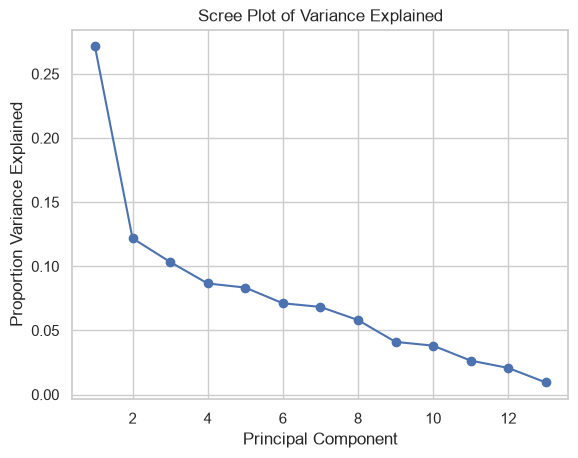

In [27]:
# Explained variance
explained_var = music_model.stages[-1].explainedVariance
print("Sum of Explained Variance:", sum(explained_var))

# Scree Plot
plt.figure()
plt.plot(np.arange(1, len(explained_var)+1), explained_var, marker='o')
plt.title("Scree Plot of Variance Explained")
plt.xlabel("Principal Component")
plt.ylabel("Proportion Variance Explained")
plt.show()


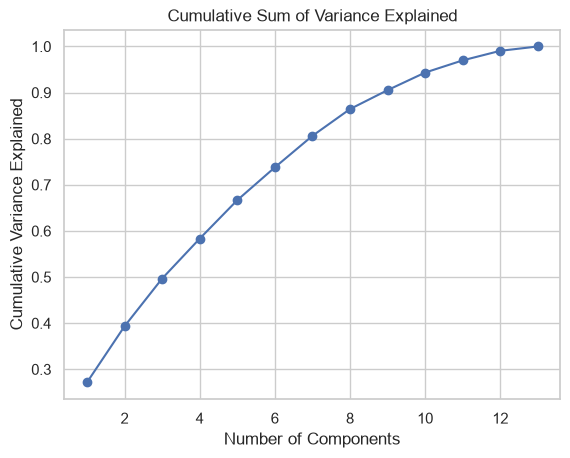

In [28]:

# Cumulative Sum of Variance Explained
cum_sum = np.cumsum(explained_var)
plt.figure()
plt.plot(np.arange(1, len(explained_var)+1), cum_sum, marker='o')
plt.title("Cumulative Sum of Variance Explained")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()


##Final PCA with k=10

In [29]:
# Final PCA with k=10 for compact song representations
music_pipe_final = Pipeline(stages=[
    VectorAssembler(inputCols=pca_features, outputCol='audio_features', handleInvalid='skip'),
    StandardScaler(withMean=True, withStd=True, inputCol='audio_features', outputCol='scaled_audio_features'),
    PCA(k=10, inputCol='scaled_audio_features', outputCol='pca_score')
])

music_model_final = music_pipe_final.fit(music_with_id_df)
music_pca_final = music_model_final.transform(music_with_id_df).cache()
print('Sum of Explained Variance with k=10:', sum(music_model_final.stages[-1].explainedVariance))
music_pca_final.select('id', 'name', 'artists', 'pca_score').show(5, truncate=False)


Sum of Explained Variance with k=10: 0.9433904133622069


+----------------------+---------------------------------------------+----------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id                    |name                                         |artists                                 |pca_score                                                                                                                                                                                                |
+----------------------+---------------------------------------------+----------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|6KbQ3uYMLKb5jDxLF7wYDD|Singende Bataillone 1. Teil       

##Recommendation System Based on PCA

In [30]:
# Recommendation system based on PCA vectors with exact, refined, and ambiguous lookup handling
def l2_dist(c1, c2):
    return float(np.sqrt((c1 - c2).T.dot((c1 - c2))))


def find_seed_tracks(df, track_id=None, song_name=None, artist_name=None, limit=10):
    if not any([track_id, song_name, artist_name]):
        raise ValueError('Provide track_id, song_name, or artist_name.')

    query = df
    if track_id is not None:
        query = query.where(fn.col('id') == track_id)
    if song_name is not None:
        query = query.where(fn.lower(fn.col('name')) == song_name.lower())
    if artist_name is not None:
        query = query.where(fn.lower(fn.col('artists')).contains(artist_name.lower()))

    return query.select('id', 'name', 'artists', 'popularity', 'year').limit(limit).toPandas()


def get_nearest_songs(song_name=None, num_nearest_songs=5, track_id=None, artist_name=None):
    candidates = find_seed_tracks(
        music_pca_final,
        track_id=track_id,
        song_name=song_name,
        artist_name=artist_name,
        limit=num_nearest_songs + 1,
    )

    if candidates.empty:
        return pd.DataFrame([{'status': 'not_found', 'message': 'No matching song was found. Try track_id, song_name, or artist_name.'}])
    if len(candidates) > 1:
        candidates.insert(0, 'status', 'ambiguous')
        return candidates

    seed_id = candidates.iloc[0]['id']
    song_df = (
        music_pca_final
        .where(fn.col('id') == seed_id)
        .select(fn.col('pca_score').alias('song_scores'))
        .join(music_pca_final)
        .where(fn.col('id') != seed_id)
        .withColumn('pca_array', vector_to_array('pca_score'))
        .withColumn('seed_array', vector_to_array('song_scores'))
        .withColumn(
            'dist',
            fn.expr(
                "sqrt(aggregate(zip_with(pca_array, seed_array, "
                "(x, y) -> pow(x - y, 2D)), 0D, (acc, x) -> acc + x))"
            ),
        )
        .orderBy(fn.asc('dist'))
        .select('id', 'name', 'artists', 'popularity', 'year', 'dist')
        .limit(num_nearest_songs)
    )

    result = song_df.toPandas()
    result.insert(0, 'status', 'ok')
    return result

# Example usage. Add artist_name or track_id if the song title is ambiguous.
get_nearest_songs(song_name='Sad Forever', num_nearest_songs=5)


,status,id,name,artists,popularity,year,dist
0,ok,4bBEH5gGRHf5YxZGqzIvMP,Foolish Pride,['Travis Tritt'],39.0,1995.0,0.293609
1,ok,1urmwhtXPiakhcqvqUi3rp,Brown Eyes,"""[""""Destiny's Child""""]""",61.0,2001.0,0.363704
2,ok,0bz0nJ3SztnFRKfSwFbhC6,My Everything,['98º'],49.0,2000.0,0.402675
3,ok,2vwlzO0Qp8kfEtzTsCXfyE,Wrecking Ball,['Miley Cyrus'],75.0,2013.0,0.467074
4,ok,7LQyaNDtdmUGnaQYmL3xZu,Pink Bullets,['The Shins'],48.0,2003.0,0.470193


##K-Means Clustering
Optimal Number of Clusters (Silhouette Score)

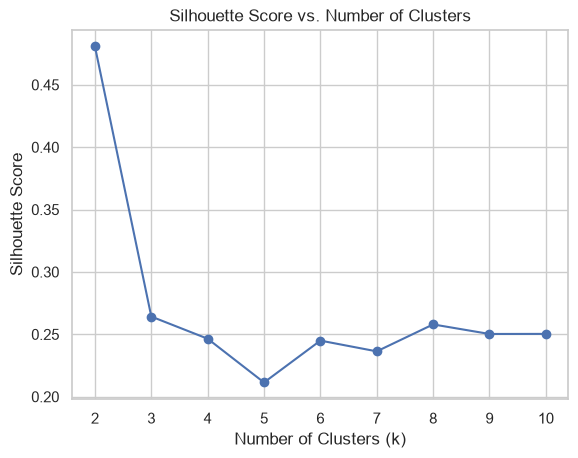

Optimal k: 2


In [31]:
# Find optimal K using scaled/PCA features instead of raw feature ranges
cluster_df = music_pca_final.select('id', 'name', 'artists', fn.col('pca_score').alias('features')).cache()

def optimal_k(df_in, k_min, k_max):
    silhouette_scores = []
    k_values = list(range(k_min, k_max + 1))
    evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction')

    for k in k_values:
        kmeans = KMeans(k=k, seed=42, featuresCol='features')
        model = kmeans.fit(df_in)
        predictions = model.transform(df_in)
        silhouette_scores.append(evaluator.evaluate(predictions))

    return k_values, silhouette_scores

k_values, silhouette_scores = optimal_k(cluster_df, k_min=2, k_max=10)

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

optimal_k_value = k_values[int(np.argmax(silhouette_scores))]
print('Optimal k:', optimal_k_value)


##Final K-Means Model

In [32]:
# Fit K-Means on PCA feature vectors
music_kmeans_model = KMeans(k=optimal_k_value, seed=42, featuresCol='features').fit(cluster_df)
music_kmeans = music_kmeans_model.transform(cluster_df).cache()

music_kmeans.select('name', 'artists', 'prediction').show()

evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction')
silhouette_score = evaluator.evaluate(music_kmeans)
print('Silhouette Score for K-Means:', silhouette_score)

freq_cluster = music_kmeans.groupby('prediction').count()
freq_cluster.orderBy('prediction').show()


+--------------------+--------------------+----------+
|                name|             artists|prediction|
+--------------------+--------------------+----------+
|Singende Bataillo...| ['Carl Woitschach']|         1|
|Fantasiestücke, O...|['Robert Schumann...|         1|
|Chapter 1.18 - Za...|['Seweryn Goszczy...|         0|
|Bebamos Juntos - ...|['Francisco Canaro']|         1|
|Polonaise-Fantais...|['Frédéric Chopin...|         1|
|Scherzo a capricc...|['Felix Mendelsso...|         1|
|Valse oubliée No....|['Franz Liszt', '...|         1|
| Per aspera ad astra| ['Carl Woitschach']|         1|
|Moneda Corriente ...|['Francisco Canar...|         1|
|Chapter 1.3 - Zam...|['Seweryn Goszczy...|         0|
|Piano Sonata No. ...|['Sergei Rachmani...|         1|
|Piano Sonata No. ...|['Frédéric Chopin...|         1|
|Piano Sonata in E...|['Samuel Barber',...|         1|
|Nachtstücke, Op. ...|['Robert Schumann...|         1|
|Symphony No. 5 in...|['Ludwig van Beet...|         1|
|A Shropsh

Silhouette Score for K-Means: 0.4807095639974681


+----------+------+
|prediction| count|
+----------+------+
|         0| 16255|
|         1|152207|
+----------+------+



## Final Practical Interpretation and Spark-vs-Pandas Summary

This final section ties the exploratory analyses, supervised models, PCA recommendation system, clustering, and big-data implementation choices together.


In [33]:
performance_summary = pd.DataFrame(performance_records)
display(performance_summary)

spark_faster_count = int((performance_summary['faster_locally'] == 'Spark').sum())
pandas_faster_count = int((performance_summary['faster_locally'] == 'Pandas').sum())

display(Markdown(
    f"""**Overall Spark-vs-Pandas conclusion.** Across the measured local operations, Spark was faster in **{spark_faster_count}** case(s) and Pandas was faster in **{pandas_faster_count}** case(s). 
This result is expected for a 169,909-row CSV on one machine: Pandas often wins small local aggregations because it avoids Spark session, scheduling, and lazy-execution action overhead. 
The project still uses Spark for the right big-data reasons: full-data DataFrame transformations, caching, reusable feature engineering, MLlib pipelines, scaling, PCA, regression, recommendation vectors, and KMeans clustering. 
The honest conclusion is that Spark is not automatically faster here, but it is the better architecture to demonstrate scalable, repeatable big-data analytics."""
))

display(Markdown(
    """**What this project practically shows.** The strongest practical contribution is a content-based music recommendation workflow supported by deeper EDA. 
The new analyses show how audio features vary by decade, how artist catalog presence differs from popularity, how popular songs differ in feature profile, how outliers should be handled carefully, and how song duration changes over time. 
The supervised popularity models are useful for comparison, but popularity remains only moderately predictable from audio features because major external drivers are missing. 
The clustering and PCA sections are useful for organizing songs by sound, while the recommendation system is useful for finding tracks with similar audio characteristics rather than personalized listener taste."""
))


,operation,spark_seconds,pandas_seconds,rows_processed,output_size,faster_locally,better_for_scale,memory_scale_note,honest_interpretation
0,row count,0.2493,0.0000,168462,1,Pandas,Spark,Pandas is fine for this local CSV; Spark count...,Pandas was faster locally; Spark overhead is e...
1,decade aggregation,3.1216,0.0617,168462,one row per decade,Pandas,Spark,Spark aggregation scales to larger files and c...,Pandas was faster locally; Spark overhead is e...
2,artist aggregation,3.7768,0.2073,168462,artists with at least 10 tracks,Pandas,Spark,Artist grouping can grow quickly with larger c...,Pandas was faster locally; Spark overhead is e...
3,popularity-band aggregation,0.8427,0.0399,168462,four popularity bands,Pandas,Spark,Banding is cheap locally; Spark makes the tran...,Pandas was faster locally; Spark overhead is e...
4,outlier quantile summary,2.1553,0.0341,168462,6 feature summaries,Pandas,Spark,Spark approximate quantiles avoid collecting f...,Pandas was faster locally; Spark overhead is e...
5,duration-band aggregation,0.5310,0.0276,168462,duration bands by decade,Pandas,Spark,Duration banding is local-friendly here; Spark...,Pandas was faster locally; Spark overhead is e...


**Overall Spark-vs-Pandas conclusion.** Across the measured local operations, Spark was faster in **0** case(s) and Pandas was faster in **6** case(s). 
This result is expected for a 169,909-row CSV on one machine: Pandas often wins small local aggregations because it avoids Spark session, scheduling, and lazy-execution action overhead. 
The project still uses Spark for the right big-data reasons: full-data DataFrame transformations, caching, reusable feature engineering, MLlib pipelines, scaling, PCA, regression, recommendation vectors, and KMeans clustering. 
The honest conclusion is that Spark is not automatically faster here, but it is the better architecture to demonstrate scalable, repeatable big-data analytics.

**What this project practically shows.** The strongest practical contribution is a content-based music recommendation workflow supported by deeper EDA. 
The new analyses show how audio features vary by decade, how artist catalog presence differs from popularity, how popular songs differ in feature profile, how outliers should be handled carefully, and how song duration changes over time. 
The supervised popularity models are useful for comparison, but popularity remains only moderately predictable from audio features because major external drivers are missing. 
The clustering and PCA sections are useful for organizing songs by sound, while the recommendation system is useful for finding tracks with similar audio characteristics rather than personalized listener taste.